# Brain cCRE enrichment

Are active regions enriched in brain cCREs compared to non-active regions? Covers:
PhyloP conservation, multi-tissue SCREEN cCRE overlap (SCREEN v3/v4), sensitivity/
specificity/F1 of SCREEN annotations as MPRA-activity predictors, cross-tissue
enrichment (Fisher exact, FDR-corrected), tissue annotation-breadth / exclusivity
(UpSet plots), and control-sequence distributions (SLEA, VISTA enhancers).

In [1]:
import os
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from pandas.errors import EmptyDataError
from upsetplot import UpSet, from_indicators

sys.path.append("../00_helpful_functions")
import helpful_functions as hf

col_name = "name"
col_header = "name"
col_sequence = "sequence"
col_category = "category"
col_class = "class"
col_source = "source"
col_ref = "ref"
col_chr = "chr"
col_start = "start"
col_end = "end"
col_strand = "strand"
col_variant_class = "variant_class"
col_variant_pos = "variant_pos"
col_SPDI = "SPDI"
col_allele = "allele"
col_info = "info"

list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele, "gene_set", "REMAP2022_TFBS_list"]

config_path = "data/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)

_ELEMENT_SIGNIFICANT_LEVEL = 0.05
writing = False  # set True to (re)write BED/output files
base_figure_dir = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/element_activity"


def add_normalization_label_column(name):
    if "scramble" in name:
        return "scrambled_ctrl"
    if "cardiac_neuro_cava_random" in name:
        return "tested"
    return "not_important_for_normalization"


def filter_library_df(df, name_col):
    keep_patterns = [
        "cardiac_neuro_cava_random", "negative_neuron_MK", "negative_neuron_NP",
        "scrambl", "positive_neuron_", "GC_", "SLEA",
    ]
    mask = False
    for pattern in keep_patterns:
        mask = mask | df[name_col].str.contains(pattern)
    return df.loc[mask].copy()

## Load element annotation table

In [2]:
element_annotation_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/data/all_80k_MPRA_elements_annotations_table_2512_eQTL_phastCons_ReMap.tsv.gz"
element_annotation_path = "data/all_80k_MPRA_elements_annotations_table_2606_eQTL_phastCons_ReMap.tsv.gz"

elements_df = pd.read_csv(element_annotation_path, sep="\t", low_memory=False)
for col in list_columns:
    elements_df[col] = elements_df[col].apply(hf.safe_eval)

elements_df["label"] = elements_df[col_name].apply(add_normalization_label_column)
elements_df["has_readout_NGN2"] = elements_df["normalized_activity_NGN2"].notna()
elements_df = filter_library_df(elements_df, col_name)

readout_tested_ref_df = elements_df.loc[
    elements_df["has_readout_NGN2"]
    & elements_df[col_name].str.contains("cardiac_neuro_cava_random")
    & ~elements_df[col_name].str.contains(":ALT_")
].copy()
readout_tested_ref_df["is_E2G_brain"] = readout_tested_ref_df["brain_e2g_gene_name"].notna()

# make significant_region_NGN2 column boolean
readout_tested_ref_df["significant_region_NGN2"] = readout_tested_ref_df["significant_region_NGN2"].astype(bool)

### Annotate with PhyloP scores
`bigWigAverageOverBed zoonomia_241-mammalian-2020v2.phylop.bigWig tested_regions_phyloP.bed tested_regions_80k_MPRA_phyloP.out.tab`

In [3]:
readout_tested_ref_df["region_id"] = (
    readout_tested_ref_df[col_chr].astype(str)
    + ":"
    + readout_tested_ref_df[col_start].astype(int).astype(str)
    + "-"
    + readout_tested_ref_df[col_end].astype(int).astype(str)
)

region_bed_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/phylop/tested_regions_phyloP.bed"
if writing:
    region_bed_df = readout_tested_ref_df[[col_chr, col_start, col_end, "region_id"]].drop_duplicates().copy()
    region_bed_df[col_start] = region_bed_df[col_start].astype(int)
    region_bed_df[col_end] = region_bed_df[col_end].astype(int)
    region_bed_df.to_csv(region_bed_path, sep="\t", header=False, index=False)

phylop_mpra_80k_path = "data/tested_regions_80k_MPRA_phyloP.out.tab"
phylop_mpra_80k = pd.read_csv(
    phylop_mpra_80k_path, sep="\t", header=None,
    names=["region_id", "size", "covered", "sum", "mean0", "mean"],
)
phylop_mpra_80k = phylop_mpra_80k.rename(
    columns={"mean0": "region_phyloP_mean0", "mean": "region_phyloP_mean_covered", "sum": "region_phyloP_sum"}
)
phylop_mpra_80k["region_phyloP_fraction_covered"] = phylop_mpra_80k["covered"] / phylop_mpra_80k["size"]

readout_tested_ref_df = readout_tested_ref_df.merge(phylop_mpra_80k, on="region_id", how="left")
print("Missing phyloP:", readout_tested_ref_df["region_phyloP_mean_covered"].isna().mean())

readout_tested_ref_df["constraint_bin"] = pd.cut(
    readout_tested_ref_df["region_phyloP_mean_covered"],
    bins=[-10, 0, 1, 2, 10],
    labels=["negative_or_fast", "weak_constraint", "moderate_constraint", "high_constraint"],
)
readout_tested_ref_df["is_constrained"] = readout_tested_ref_df["region_phyloP_mean_covered"] > 1
readout_tested_ref_df["is_highly_constrained"] = readout_tested_ref_df["region_phyloP_mean_covered"] > 2

for gene_set in ["neuro", "cardiac", "cava", "random"]:
    readout_tested_ref_df[f"is_{gene_set}"] = readout_tested_ref_df["gene_set"].apply(
        lambda x: gene_set in x if isinstance(x, list) else False
    )

Missing phyloP: 0.0


### Annotate with Zoonomia RoCC constraint (binary overlap, no arbitrary threshold)
`01_design_overview_panel.py`'s `add_rocc_constraint_annotation()` defines "constrained"
as a binary call (does the region overlap a Zoonomia RoCC at all) rather than a phyloP
score threshold. Kept as separate `is_rocc_constrained` columns alongside the existing
phyloP-threshold-based `is_constrained`/`is_highly_constrained` above. The constraint-
enrichment analyses below run both definitions side by side so the two can be compared
before deciding whether to keep one, the other, or both.

In [4]:
import pyranges as pr

rocc_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/zoonomia_constrint_regions/RoCCs.bed.gz"
rocc_path = "data/RoCCs.bed.gz"

rocc_df = pd.read_csv(rocc_path, sep="\t", header=None, compression="gzip").iloc[:, :3]
rocc_df.columns = ["Chromosome", "Start", "End"]
rocc_pr = pr.PyRanges(rocc_df)

regions_pr = pr.PyRanges(
    readout_tested_ref_df[[col_chr, col_start, col_end, "region_id"]]
    .drop_duplicates(subset="region_id")
    .astype({col_start: int, col_end: int})
    .rename(columns={col_chr: "Chromosome", col_start: "Start", col_end: "End"})
)

rocc_overlap = regions_pr.join(rocc_pr).as_df()
if rocc_overlap.empty:
    n_bp_rocc_constrained = pd.DataFrame(columns=["region_id", "n_bp_rocc_constrained"])
else:
    rocc_overlap["overlap_bp"] = (
        rocc_overlap[["End", "End_b"]].min(axis=1) - rocc_overlap[["Start", "Start_b"]].max(axis=1)
    ).clip(lower=0)
    n_bp_rocc_constrained = (
        rocc_overlap.groupby("region_id")["overlap_bp"].sum().reset_index(name="n_bp_rocc_constrained")
    )

readout_tested_ref_df = readout_tested_ref_df.merge(n_bp_rocc_constrained, on="region_id", how="left")
readout_tested_ref_df["n_bp_rocc_constrained"] = readout_tested_ref_df["n_bp_rocc_constrained"].fillna(0)
readout_tested_ref_df["frac_bp_rocc_constrained"] = readout_tested_ref_df["n_bp_rocc_constrained"] / (
    readout_tested_ref_df[col_end].astype(int) - readout_tested_ref_df[col_start].astype(int)
)
readout_tested_ref_df["is_rocc_constrained"] = readout_tested_ref_df["n_bp_rocc_constrained"] > 0
print("RoCC-constrained fraction of regions:", readout_tested_ref_df["is_rocc_constrained"].mean())
print(
    "Agreement between phyloP-threshold and RoCC-binary constraint calls:",
    (readout_tested_ref_df["is_constrained"] == readout_tested_ref_df["is_rocc_constrained"]).mean(),
)

RoCC-constrained fraction of regions: 0.0956344349245206
Agreement between phyloP-threshold and RoCC-binary constraint calls: 0.9177070583435333


In [5]:
# two constraint definitions run side by side throughout this section: the original
# phyloP-threshold-based call, and the RoCC-binary-overlap call added above
constraint_definitions = [
    ("is_constrained", "phyloP-threshold (mean_covered > 1)"),
    ("is_rocc_constrained", "RoCC-binary overlap"),
]


def summarize_constraint(df_subset, label, constraint_col):
    print(f"\n=== {label} [{constraint_col}] ===")
    print(f"N regions: {len(df_subset)}")
    print(f"Proportion constrained: {df_subset[constraint_col].mean():.4f}")
    if constraint_col == "is_constrained":
        print(f"Proportion highly constrained (>2): {df_subset['is_highly_constrained'].mean():.4f}")


for constraint_col, constraint_label in constraint_definitions:
    for gene_set in ["neuro", "cardiac", "cava", "random"]:
        subset = readout_tested_ref_df[readout_tested_ref_df[f"is_{gene_set}"]]
        summarize_constraint(subset, f"Gene set: {gene_set}", constraint_col)
        summarize_constraint(subset[subset["significant_region_NGN2"]], f"{gene_set} | significant", constraint_col)
        summarize_constraint(subset[~subset["significant_region_NGN2"]], f"{gene_set} | not significant", constraint_col)


=== Gene set: neuro [is_constrained] ===
N regions: 15441
Proportion constrained: 0.1722
Proportion highly constrained (>2): 0.0861

=== neuro | significant [is_constrained] ===
N regions: 1099
Proportion constrained: 0.2757
Proportion highly constrained (>2): 0.1601

=== neuro | not significant [is_constrained] ===
N regions: 14342
Proportion constrained: 0.1643
Proportion highly constrained (>2): 0.0804

=== Gene set: cardiac [is_constrained] ===
N regions: 7671
Proportion constrained: 0.1430
Proportion highly constrained (>2): 0.0615

=== cardiac | significant [is_constrained] ===
N regions: 491
Proportion constrained: 0.2688
Proportion highly constrained (>2): 0.1426

=== cardiac | not significant [is_constrained] ===
N regions: 7180
Proportion constrained: 0.1344
Proportion highly constrained (>2): 0.0560

=== Gene set: cava [is_constrained] ===
N regions: 1753
Proportion constrained: 0.1472
Proportion highly constrained (>2): 0.0593

=== cava | significant [is_constrained] ===
N

In [6]:
def fisher_test_binary(df, group_col, value_col, group1, group2):
    """Compare the proportion of value_col==True between two groups of group_col."""
    g1, g2 = df[df[group_col] == group1], df[df[group_col] == group2]
    a, c = g1[value_col].sum(), g2[value_col].sum()
    table = [[a, len(g1) - a], [c, len(g2) - c]]
    oddsratio, p = fisher_exact(table)
    return {
        "group1": group1, "group2": group2, "odds_ratio": oddsratio, "p_value": p,
        "n1": len(g1), "n2": len(g2), "prop1": a / len(g1), "prop2": c / len(g2),
    }


results = []
for constraint_col, constraint_label in constraint_definitions:
    for gene_set in ["neuro", "cardiac", "cava", "random"]:
        subset = readout_tested_ref_df[readout_tested_ref_df[f"is_{gene_set}"]].copy()
        subset["group"] = np.where(subset["significant_region_NGN2"], "significant", "not_significant")
        res = fisher_test_binary(subset, "group", constraint_col, "significant", "not_significant")
        res["gene_set"] = gene_set
        res["constraint_definition"] = constraint_label
        results.append(res)

constraint_enrichment_stats = pd.DataFrame(results)
# FDR-correct within each constraint definition separately, matching what a single-
# definition run would have produced (not pooled across both definitions)
constraint_enrichment_stats["p_adj"] = constraint_enrichment_stats.groupby("constraint_definition")[
    "p_value"
].transform(lambda p: multipletests(p, method="fdr_bh")[1])
print(constraint_enrichment_stats.sort_values(["constraint_definition", "p_value"]))

        group1           group2  odds_ratio       p_value    n1     n2  \
4  significant  not_significant    2.841553  9.714996e-36  1099  14342   
5  significant  not_significant    3.828602  6.576525e-25   491   7180   
7  significant  not_significant    3.096601  8.180345e-03    52    616   
6  significant  not_significant    1.152476  6.056685e-01   114   1639   
0  significant  not_significant    1.936549  7.418498e-19  1099  14342   
1  significant  not_significant    2.368063  5.086861e-14   491   7180   
3  significant  not_significant    2.274296  3.656965e-02    52    616   
2  significant  not_significant    1.421610  1.703902e-01   114   1639   

      prop1     prop2 gene_set                constraint_definition  \
4  0.228389  0.094338    neuro                  RoCC-binary overlap   
5  0.221996  0.069359  cardiac                  RoCC-binary overlap   
7  0.173077  0.063312   random                  RoCC-binary overlap   
6  0.096491  0.084808     cava                  R

In [7]:
# pairwise gene-set-vs-gene-set comparisons (e.g. is neuro more constrained/significant
# than cardiac?), distinct from the significant-vs-not-significant test above. Run for
# both constraint definitions side by side; the significance-only comparison doesn't
# depend on the constraint definition, so it's computed once.
gene_sets = ["neuro", "cardiac", "cava", "random"]

readout_tested_ref_df["gene_set_label"] = readout_tested_ref_df["gene_set"].apply(
    lambda x: "+".join(x) if isinstance(x, list) and x else "None"
)
pairwise_constraint_results = []
pairwise_significance_results = []
for g1 in gene_sets:
    for g2 in gene_sets:
        if g1 >= g2:
            continue
        for constraint_col, constraint_label in constraint_definitions:
            res_constraint = fisher_test_binary(readout_tested_ref_df, "gene_set_label", constraint_col, g1, g2)
            res_constraint["constraint_definition"] = constraint_label
            pairwise_constraint_results.append(res_constraint)
        res_significance = fisher_test_binary(
            readout_tested_ref_df, "gene_set_label", "significant_region_NGN2", g1, g2
        )
        pairwise_significance_results.append(res_significance)

pairwise_constraint_stats = pd.DataFrame(pairwise_constraint_results)
pairwise_constraint_stats["p_adj"] = pairwise_constraint_stats.groupby("constraint_definition")[
    "p_value"
].transform(lambda p: multipletests(p, method="fdr_bh")[1])
print(pairwise_constraint_stats.sort_values(["constraint_definition", "p_value"]))

pairwise_significance_stats = pd.DataFrame(pairwise_significance_results)
pairwise_significance_stats["p_adj"] = multipletests(pairwise_significance_stats["p_value"], method="fdr_bh")[1]
print(pairwise_significance_stats.sort_values("p_value"))



     group1  group2  odds_ratio       p_value     n1     n2     prop1  \
3   cardiac   neuro    0.761615  8.237267e-08   6802  14522  0.083358   
9      cava   neuro    0.705969  3.222137e-04   1505  14522  0.077741   
1     neuro  random    1.542274  3.604379e-03  14522    668  0.106666   
7   cardiac  random    1.174619  3.374816e-01   6802    668  0.083358   
5   cardiac    cava    1.078823  5.006924e-01   6802   1505  0.083358   
11     cava  random    1.088797  6.617539e-01   1505    668  0.077741   
2   cardiac   neuro    0.826877  2.100509e-06   6802  14522  0.149809   
0     neuro  random    1.659924  1.698002e-05  14522    668  0.175665   
8      cava   neuro    0.760973  3.326407e-04   1505  14522  0.139535   
6   cardiac  random    1.372553  1.157268e-02   6802    668  0.149809   
10     cava  random    1.263158  1.136081e-01   1505    668  0.139535   
4   cardiac    cava    1.086604  3.162183e-01   6802   1505  0.149809   

       prop2                constraint_definition 

### Multi-tissue SCREEN cCRE annotation
brain / heart / H1 already come from the element annotation table; add the remaining
cell types (NPC, neural stem, excitatory neuron, WTC11, H9) plus all other SCREEN
tissues used downstream, and the SCREEN v3-vs-v4 ID check.

In [8]:
def add_SCREEN_CRE_info(df, config_info, new_name, screen_id_col="SCREEN_ID"):
    """Flag whether an element's SCREEN_ID is an active cCRE in the given tissue bed."""
    path = config["files"]["creating"][config_info]
    try:
        screen_ids = pd.read_csv(path, sep="\t", header=None, usecols=[3])[3]
    except EmptyDataError:
        df[new_name] = pd.Series(False, index=df.index, dtype="boolean")
        return df
    df[new_name] = df[screen_id_col].isin(screen_ids).astype("boolean")
    return df


def add_SCREEN_CRE_annotation_group_info(df, config_info, new_name, screen_id_col="SCREEN_ID"):
    """Flag each cCRE class (PLS, dELS, pELS, ...) separately, e.g. is_NPC_SCREEN_pELS."""
    path = config["files"]["creating"][config_info]
    try:
        screen_regions = pd.read_csv(
            path, sep="\t", header=None, usecols=[3, 9], names=[screen_id_col, "annotation"]
        )
    except EmptyDataError:
        return df
    for annotation, ids in screen_regions.groupby("annotation")[screen_id_col]:
        df[f"{annotation}_{new_name}"] = df[screen_id_col].isin(ids).astype("boolean")
    return df


extra_cell_types = {
    "is_NPC_SCREEN_cCRE": "npc_screen_active_cre",
    "is_neural_stem_SCREEN_cCRE": "neural_stem_cell_screen_active_cre",
    "is_excitatory_neuron_SCREEN_cCRE": "gluta_screen_active_cre",
    "is_WTC11_SCREEN_cCRE": "WTC11_screen_active_cre",
    "is_H9_SCREEN_cCRE": "H9_screen_active_cre",
}
for new_name, config_info in extra_cell_types.items():
    readout_tested_ref_df = add_SCREEN_CRE_info(readout_tested_ref_df, config_info, new_name)

readout_tested_ref_df["is_npc_or_excitatory_NSC_SCREEN_cre"] = (
    readout_tested_ref_df["is_excitatory_neuron_SCREEN_cCRE"]
    | readout_tested_ref_df["is_NPC_SCREEN_cCRE"]
    | readout_tested_ref_df["is_neural_stem_SCREEN_cCRE"]
)

In [9]:
# every SCREEN tissue used anywhere downstream (enrichment dicts, tissue-breadth analysis)
screen_tissues = [
    "adrenal_gland", "blood", "blood_vessel", "bone_marrow", "bone", "breast",
    "connective_tissue", "embryo", "epithelium", "esophagus", "eye", "gallblader",
    "kidney", "large_intestine", "limb", "liver", "lung", "lymphoid_tissue", "mouth",
    "muscle", "nerve", "nose", "ovary", "pancreas", "penis", "placenta", "prostate",
    "skin", "small_intestine", "spinal_cord", "spleen", "stomach", "testis", "thymus",
    "thyroid", "uterus", "vagina", "urinary_bladder_dnase", "urinary_bladder_acety_methy",
    "parathyroid_adenoma", "adipose",
]
for tissue in screen_tissues:
    readout_tested_ref_df = add_SCREEN_CRE_info(
        readout_tested_ref_df, f"{tissue}_screen_active_cre", f"is_{tissue}_SCREEN_cCRE"
    )
readout_tested_ref_df["is_urinary_bladder_SCREEN_cCRE"] = (
    readout_tested_ref_df["is_urinary_bladder_dnase_SCREEN_cCRE"]
    | readout_tested_ref_df["is_urinary_bladder_acety_methy_SCREEN_cCRE"]
)
readout_tested_ref_df["is_all_CRE"] = True

In [10]:
# SCREEN v3-vs-v4 ID check: some SCREEN_IDs used in the 80K design (v3) are no longer
# present in the current GRCh38-cCREs v4 release.
screen_v4_df_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/GRCh38-cCREs.bed.gz"
screen_v4_df = pd.read_csv(
    screen_v4_df_path, sep="\t", header=None,
    names=["chr", "start", "end", "broken_SCREEN_ID", "SCREEN_ID", "class"],
)
screen_v4_df["screen_v4_annotation"] = True
readout_tested_ref_df = readout_tested_ref_df.merge(
    screen_v4_df[["SCREEN_ID", "screen_v4_annotation"]], on="SCREEN_ID", how="left"
)
readout_tested_ref_df["screen_v4_annotation"] = readout_tested_ref_df["screen_v4_annotation"].fillna(False)
readout_tested_ref_df["is_onlyv3_SCREEN_cCRE"] = ~readout_tested_ref_df["screen_v4_annotation"]
print(readout_tested_ref_df["is_onlyv3_SCREEN_cCRE"].value_counts())

is_onlyv3_SCREEN_cCRE
False    23789
True       721
Name: count, dtype: int64


/tmp/ipykernel_208004/2917618166.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  readout_tested_ref_df["screen_v4_annotation"] = readout_tested_ref_df["screen_v4_annotation"].fillna(False)


In [11]:


# --- the two SCREEN tissue dicts used throughout the rest of this notebook ---
# screen_cols_all_cell_types: used for the enrichment analysis and UpSet plots (49
# entries, includes cell-type/model-system flags and "only v3").
screen_cols_all_cell_types = {
    "neural stem cell": "is_neural_stem_SCREEN_cCRE",
    "neural progenitor": "is_NPC_SCREEN_cCRE",
    "heart": "is_heart_SCREEN_cCRE",
    "H1": "is_H1_SCREEN_cCRE",
    "H9": "is_H9_SCREEN_cCRE",
    "excitatory neuron": "is_excitatory_neuron_SCREEN_cCRE",
    "WTC11": "is_WTC11_SCREEN_cCRE",
    "only v3": "is_onlyv3_SCREEN_cCRE",
    "brain": "is_brain_SCREEN_cCRE",
    "adrenal gland": "is_adrenal_gland_SCREEN_cCRE",
    "blood": "is_blood_SCREEN_cCRE",
    "blood vessel": "is_blood_vessel_SCREEN_cCRE",
    "bone marrow": "is_bone_marrow_SCREEN_cCRE",
    "bone": "is_bone_SCREEN_cCRE",
    "breast": "is_breast_SCREEN_cCRE",
    "connective tissue": "is_connective_tissue_SCREEN_cCRE",
    "embryo": "is_embryo_SCREEN_cCRE",
    "epithelium": "is_epithelium_SCREEN_cCRE",
    "esophagus": "is_esophagus_SCREEN_cCRE",
    "eye": "is_eye_SCREEN_cCRE",
    "gallbladder": "is_gallblader_SCREEN_cCRE",
    "kidney": "is_kidney_SCREEN_cCRE",
    "large intestine": "is_large_intestine_SCREEN_cCRE",
    "limb": "is_limb_SCREEN_cCRE",
    "liver": "is_liver_SCREEN_cCRE",
    "lung": "is_lung_SCREEN_cCRE",
    "lymphoid tissue": "is_lymphoid_tissue_SCREEN_cCRE",
    "mouth": "is_mouth_SCREEN_cCRE",
    "muscle": "is_muscle_SCREEN_cCRE",
    "nerve": "is_nerve_SCREEN_cCRE",
    "nose": "is_nose_SCREEN_cCRE",
    "ovary": "is_ovary_SCREEN_cCRE",
    "pancreas": "is_pancreas_SCREEN_cCRE",
    "penis": "is_penis_SCREEN_cCRE",
    "placenta": "is_placenta_SCREEN_cCRE",
    "prostate": "is_prostate_SCREEN_cCRE",
    "skin": "is_skin_SCREEN_cCRE",
    "small intestine": "is_small_intestine_SCREEN_cCRE",
    "spinal cord": "is_spinal_cord_SCREEN_cCRE",
    "spleen": "is_spleen_SCREEN_cCRE",
    "stomach": "is_stomach_SCREEN_cCRE",
    "testis": "is_testis_SCREEN_cCRE",
    "thymus": "is_thymus_SCREEN_cCRE",
    "thyroid": "is_thyroid_SCREEN_cCRE",
    "uterus": "is_uterus_SCREEN_cCRE",
    "vagina": "is_vagina_SCREEN_cCRE",
    "urinary_bladder": "is_urinary_bladder_SCREEN_cCRE",
    "parathyroid_adenoma": "is_parathyroid_adenoma_SCREEN_cCRE",
    "adipose": "is_adipose_SCREEN_cCRE",
}

In [12]:
# screen_cols_all_tissue_types: the subset with usable SCREEN cCRE data for the
# per-tissue "fraction active" plots and tissue-breadth analysis (37 entries; no
# nose/parathyroid/urinary_bladder — no cCRE data available for those; no cell-type
# or model-system flags).
screen_cols_all_tissue_types = {
    "adipose": "is_adipose_SCREEN_cCRE",
    "adrenal gland": "is_adrenal_gland_SCREEN_cCRE",
    "blood": "is_blood_SCREEN_cCRE",
    "blood vessel": "is_blood_vessel_SCREEN_cCRE",
    "bone": "is_bone_SCREEN_cCRE",
    "bone marrow": "is_bone_marrow_SCREEN_cCRE",
    "brain": "is_brain_SCREEN_cCRE",
    "breast": "is_breast_SCREEN_cCRE",
    "connective tissue": "is_connective_tissue_SCREEN_cCRE",
    "embryo": "is_embryo_SCREEN_cCRE",
    "epithelium": "is_epithelium_SCREEN_cCRE",
    "esophagus": "is_esophagus_SCREEN_cCRE",
    "eye": "is_eye_SCREEN_cCRE",
    "heart": "is_heart_SCREEN_cCRE",
    "gallbladder": "is_gallblader_SCREEN_cCRE",
    "kidney": "is_kidney_SCREEN_cCRE",
    "large intestine": "is_large_intestine_SCREEN_cCRE",
    "limb": "is_limb_SCREEN_cCRE",
    "liver": "is_liver_SCREEN_cCRE",
    "lung": "is_lung_SCREEN_cCRE",
    "lymphoid tissue": "is_lymphoid_tissue_SCREEN_cCRE",
    "mouth": "is_mouth_SCREEN_cCRE",
    "muscle": "is_muscle_SCREEN_cCRE",
    "nerve": "is_nerve_SCREEN_cCRE",
    "ovary": "is_ovary_SCREEN_cCRE",
    "pancreas": "is_pancreas_SCREEN_cCRE",
    "penis": "is_penis_SCREEN_cCRE",
    "placenta": "is_placenta_SCREEN_cCRE",
    "prostate": "is_prostate_SCREEN_cCRE",
    "skin": "is_skin_SCREEN_cCRE",
    "small intestine": "is_small_intestine_SCREEN_cCRE",
    "spinal cord": "is_spinal_cord_SCREEN_cCRE",
    "spleen": "is_spleen_SCREEN_cCRE",
    "stomach": "is_stomach_SCREEN_cCRE",
    "testis": "is_testis_SCREEN_cCRE",
    "thymus": "is_thymus_SCREEN_cCRE",
    "thyroid": "is_thyroid_SCREEN_cCRE",
    "uterus": "is_uterus_SCREEN_cCRE",
    "vagina": "is_vagina_SCREEN_cCRE",
}

In [13]:
# screen_cols: the small cell-type-focused subset (9 entries) used specifically for
# the two "cell-type only" UpSet plots below (not the same as either dict above).
screen_cols = {
    "brain": "is_brain_SCREEN_cCRE",
    "excitatory": "is_excitatory_neuron_SCREEN_cCRE",
    "npc_or_nsc": "is_npc_or_excitatory_NSC_SCREEN_cre",
    "neural_stem": "is_neural_stem_SCREEN_cCRE",
    "neural_progen": "is_NPC_SCREEN_cCRE",
    "heart": "is_heart_SCREEN_cCRE",
    "H1": "is_H1_SCREEN_cCRE",
    "H9": "is_H9_SCREEN_cCRE",
    "only v3": "is_onlyv3_SCREEN_cCRE",
}



### Sensitivity, specificity, precision, F1 of SCREEN annotations as MPRA-activity predictors
The original notebook also ran a standalone brain-cCRE-vs-activity Fisher exact test
here (odds ratio + p-value on the same TP/FP/FN/TN counts as below, dated "16.12":
OR test on 580/1108/7003/15819). That table is a subset of the systematic cross-tissue
Fisher enrichment further down (`compute_screen_enrichment` over all SCREEN tissues,
restricted to SCREEN-v4-annotated elements), which includes "brain" as one of the 49
tested tissues and supersedes it with a more complete (FDR-corrected, all-tissue)
version of the same test — the standalone version is omitted here as redundant.

In [14]:
def compute_confusion_and_metrics(df, annotation_col, label_col="significant_region_NGN2"):
    """
    2x2 contingency table + sensitivity/specificity/precision/F1, treating the
    annotation as a classifier predicting MPRA activity.
    """
    a = df[annotation_col].astype(bool)
    b = df[label_col].astype(bool)
    TP, FP, FN, TN = (a & b).sum(), (a & ~b).sum(), (~a & b).sum(), (~a & ~b).sum()
    return {
        "annotation": annotation_col, "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Sensitivity (TPR)": TP / (TP + FN) if (TP + FN) > 0 else np.nan,
        "Specificity (TNR)": TN / (TN + FP) if (TN + FP) > 0 else np.nan,
        "Precision (PPV)": TP / (TP + FP) if (TP + FP) > 0 else np.nan,
        "F1-score": (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else np.nan,
    }


for annotation_col in ["is_brain_SCREEN_cCRE", "is_excitatory_neuron_SCREEN_cCRE", "is_all_CRE"]:
    print(compute_confusion_and_metrics(readout_tested_ref_df, annotation_col))



{'annotation': 'is_brain_SCREEN_cCRE', 'TP': np.int64(580), 'FP': np.int64(7003), 'FN': np.int64(1108), 'TN': np.int64(15819), 'Sensitivity (TPR)': np.float64(0.34360189573459715), 'Specificity (TNR)': np.float64(0.6931469634563141), 'Precision (PPV)': np.float64(0.07648687854411183), 'F1-score': np.float64(0.12512134613310322)}
{'annotation': 'is_excitatory_neuron_SCREEN_cCRE', 'TP': np.int64(48), 'FP': np.int64(238), 'FN': np.int64(1640), 'TN': np.int64(22584), 'Sensitivity (TPR)': np.float64(0.02843601895734597), 'Specificity (TNR)': np.float64(0.9895714661291736), 'Precision (PPV)': np.float64(0.16783216783216784), 'F1-score': np.float64(0.0486322188449848)}
{'annotation': 'is_all_CRE', 'TP': np.int64(1688), 'FP': np.int64(22822), 'FN': np.int64(0), 'TN': np.int64(0), 'Sensitivity (TPR)': np.float64(1.0), 'Specificity (TNR)': np.float64(0.0), 'Precision (PPV)': np.float64(0.06886984904120767), 'F1-score': np.float64(0.12886479883960608)}


### Proportion of significantly active regions with/without SCREEN annotation

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_effect_proportions(
    df,
    group_col,
    effect_col,
    group_label_map,
    effect_stack_order=None,
    effect_colors=None,
    title="Proportion of significantly active regions",
    ylabel="Proportion",
    figsize=(7, 6),
    y_lim=(0, 1),
    absolute_bar_width=0.3,  # fixed numeric width
    text_annotation_y_pos=0.05,
    rotate=False,
    col_significant="NGN2_different_active_to_scrambled",
    fixed_xlim=(-0.75, 0.75),  # same x-axis range for ALL plots
):
    """
    Stacked barplot of effect proportions with visually identical bar widths
    across plots, even when the number of groups differs (e.g. 1 vs 2).
    """

    # Defaults
    if effect_stack_order is None:
        effect_stack_order = ["increasing", "decreasing", "not_significant"]

    if effect_colors is None:
        effect_colors = {
            "decreasing": "#E99675",
            "increasing": "#72B6A1",
            "not_significant": "lightgray",
        }

    plot_df = df.copy()
    plot_df["group_mapped"] = plot_df[group_col].map(group_label_map)

    # Proportions per group
    proportions = (
        plot_df.groupby("group_mapped")[effect_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

    # Ensure all requested effects are present
    for col in effect_stack_order:
        if col not in proportions.columns:
            proportions[col] = 0.0

    proportions = proportions[effect_stack_order]
    groups = proportions.index.tolist()
    n_groups = len(groups)

    # -------- Fixed x coordinates inside a fixed x-range --------
    # All plots share the same xlim, so visual bar width is comparable.
    x_min, x_max = fixed_xlim
    x_range = x_max - x_min

    if n_groups == 1:
        # Single bar centered
        x = np.array([0.0])
    elif n_groups == 2:
        # Two bars symmetrically around 0, within the fixed range
        # You can tune these positions if you like
        offset = x_range * 0.2
        x = np.array([-offset, offset])
    else:
        # Fallback: spread groups evenly across the fixed range
        x = np.linspace(x_min + x_range * 0.25, x_max - x_range * 0.25, n_groups)

    # -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    bottoms = np.zeros(n_groups)

    # Draw stacked bars
    for effect in effect_stack_order:
        vals = proportions[effect].values

        ax.bar(
            x,
            vals,
            width=absolute_bar_width,
            bottom=bottoms,
            color=effect_colors[effect],
            edgecolor="none",
            label=effect,
        )
        bottoms += vals

    # Axes formatting
    ax.set_xlim(fixed_xlim)  # <-- this is the critical part
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(*y_lim)

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    if rotate:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Legend
    ax.legend(
        title="Effect Type",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    # N annotations
    for xi, group_label in zip(x, groups):
        grouped_df = plot_df[plot_df["group_mapped"] == group_label]
        n_sig = grouped_df[grouped_df[col_significant]].shape[0]

        ax.text(
            xi,
            text_annotation_y_pos,
            f"N={n_sig}",
            ha="center",
            fontsize=15,
            color="dimgray",
            weight="bold",
        )

    # Percent labels
    bottoms = np.zeros(n_groups)
    for effect in effect_stack_order:
        vals = proportions[effect].values
        for xi, v, base in zip(x, vals, bottoms):
            if v > 0.01:
                ax.text(
                    xi,
                    base + v / 2,
                    f"{round(v*100,1)}%",
                    ha="center",
                    va="center",
                    fontsize=16,
                    color="white" if effect != "not_significant" else "black",
                    weight="bold",
                )
        bottoms += vals

    fig.tight_layout()
    return ax

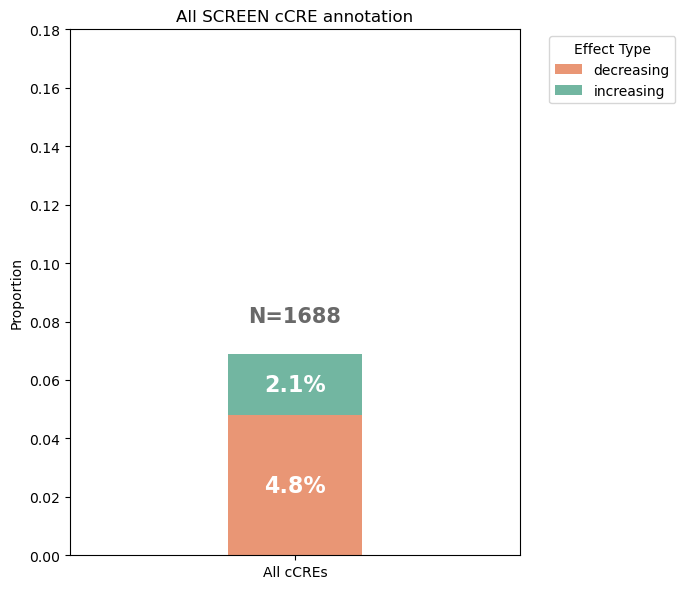

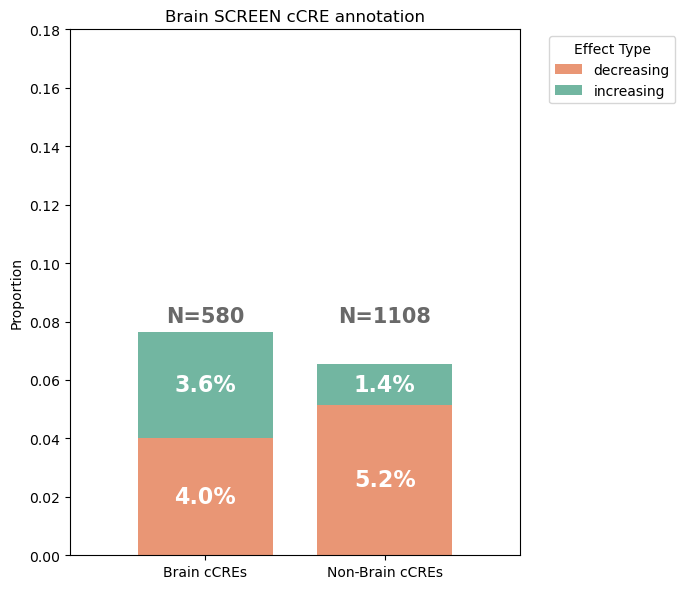

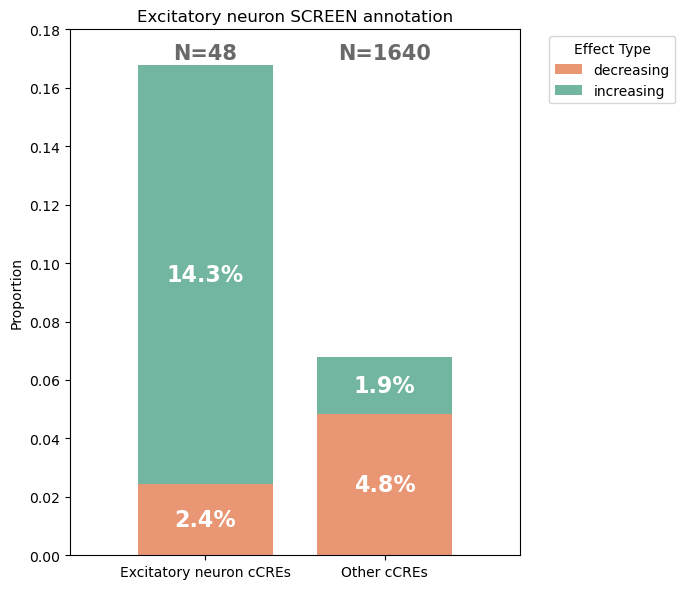

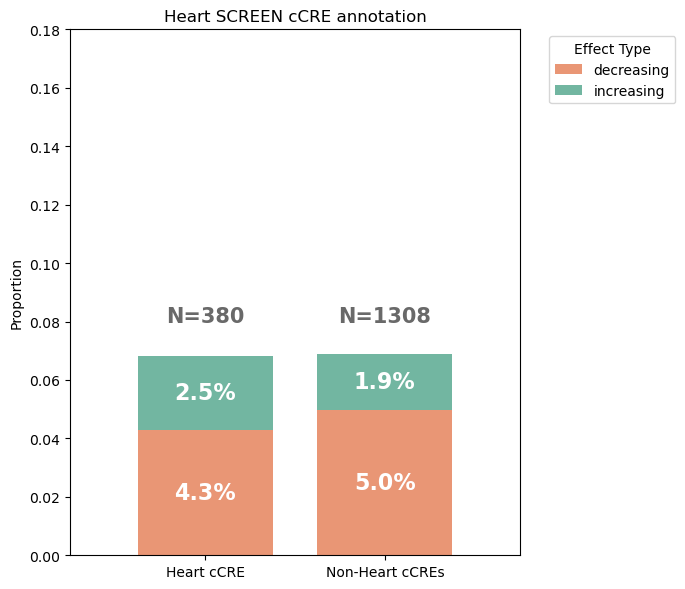

In [16]:
for group_col, labels, title, text_annotation_y_pos, output_path in [
    ("is_all_CRE", {True: "All cCREs", False: "Other cCREs"}, "All SCREEN cCRE annotation", 0.08, "2606_signifiant_activity_prop_all_CRE_vs_other.png"),
    ("is_brain_SCREEN_cCRE", {True: "Brain cCREs", False: "Non-Brain cCREs"}, "Brain SCREEN cCRE annotation", 0.08, "2606_signifiant_activity_prop_brain_vs_non_brain.png"),
    ("is_excitatory_neuron_SCREEN_cCRE", {True: "Excitatory neuron cCREs", False: "Other cCREs"}, "Excitatory neuron SCREEN annotation", 0.17, "2606_signifiant_activity_prop_excitatory_vs_other.png"),
    ("is_heart_SCREEN_cCRE", {True: "Heart cCRE", False: "Non-Heart cCREs"}, "Heart SCREEN cCRE annotation", 0.08, "2606_signifiant_activity_prop_heart_vs_non_heart.png"),
]:

    ax = plot_effect_proportions(
        df=readout_tested_ref_df, group_col=group_col, effect_col="effect_direction_NGN2",
        group_label_map=labels, title=title, col_significant="significant_region_NGN2",
        effect_stack_order=["decreasing", "increasing"],
        figsize=(7, 6),
        y_lim=(0, 0.18),
        text_annotation_y_pos=text_annotation_y_pos,
        absolute_bar_width=0.45,
        rotate=False,
    )

    if writing:
        output_path_full = os.path.join(base_figure_dir, output_path)
        output_path_svg = output_path_full.rsplit(".", 1)[0] + ".svg"
        output_path_png = output_path_full.rsplit(".", 1)[0] + ".png"
        plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
        plt.savefig(output_path_png, dpi=300, bbox_inches="tight")

    plt.show()

In [17]:
def report_screen_enrichment_numbers(df, annotation_col, label):
    """Print numbers/ratios of significantly active regions with/without a SCREEN annotation."""
    n_annotated = df[annotation_col].sum()
    n_total = df.shape[0]
    n_sig = df["significant_region_NGN2"].sum()
    n_sig_annotated = df.loc[df[annotation_col] & df["significant_region_NGN2"]].shape[0]
    n_sig_not_annotated = df.loc[~df[annotation_col] & df["significant_region_NGN2"]].shape[0]
    n_not_annotated = n_total - n_annotated

    print(f"\n=== {label} ===")
    print(f"Proportion of {label} cCREs: {n_annotated}/{n_total} = {n_annotated/n_total:.2%}")
    print(f"Significantly active {label} cCREs: {n_sig_annotated}/{n_annotated} = {n_sig_annotated/n_annotated:.2%}")
    print(f"Significantly active non-{label} cCREs: {n_sig_not_annotated}/{n_not_annotated} = {n_sig_not_annotated/n_not_annotated:.2%}")
    print(f"Proportion of {label} cCREs among all significantly active cCREs: {n_sig_annotated}/{n_sig} = {n_sig_annotated/n_sig:.2%}")


report_screen_enrichment_numbers(readout_tested_ref_df, "is_brain_SCREEN_cCRE", "brain")
report_screen_enrichment_numbers(readout_tested_ref_df, "is_excitatory_neuron_SCREEN_cCRE", "excitatory neuron")


=== brain ===
Proportion of brain cCREs: 7583/24510 = 30.94%
Significantly active brain cCREs: 580/7583 = 7.65%
Significantly active non-brain cCREs: 1108/16927 = 6.55%
Proportion of brain cCREs among all significantly active cCREs: 580/1688 = 34.36%

=== excitatory neuron ===
Proportion of excitatory neuron cCREs: 286/24510 = 1.17%
Significantly active excitatory neuron cCREs: 48/286 = 16.78%
Significantly active non-excitatory neuron cCREs: 1640/24224 = 6.77%
Proportion of excitatory neuron cCREs among all significantly active cCREs: 48/1688 = 2.84%


In [18]:
from scipy.stats import fisher_exact
import pandas as pd

# Keep only significantly active cCREs
df_sig = readout_tested_ref_df[
    readout_tested_ref_df["significant_region_NGN2"]
].copy()

# Build the contingency table automatically
brain_inc = (
    (df_sig["is_brain_SCREEN_cCRE"])
    & (df_sig["effect_direction_NGN2"] == "increasing")
).sum()

brain_dec = (
    (df_sig["is_brain_SCREEN_cCRE"])
    & (df_sig["effect_direction_NGN2"] == "decreasing")
).sum()

nonbrain_inc = (
    (~df_sig["is_brain_SCREEN_cCRE"])
    & (df_sig["effect_direction_NGN2"] == "increasing")
).sum()

nonbrain_dec = (
    (~df_sig["is_brain_SCREEN_cCRE"])
    & (df_sig["effect_direction_NGN2"] == "decreasing")
).sum()

# Contingency table
table = [[brain_inc, brain_dec], [nonbrain_inc, nonbrain_dec]]

oddsratio, pvalue = fisher_exact(table, alternative="two-sided")

print("Counts:")
print(f"Brain     increasing={brain_inc}, decreasing={brain_dec}")
print(f"Non-brain increasing={nonbrain_inc}, decreasing={nonbrain_dec}")

print("\n2×2 contingency table:")
print(table)

print(f"\nFisher exact test p-value: {pvalue:.3e}")
print(f"Odds ratio (non-brain bias toward increasing): {oddsratio:.2f}")

Counts:
Brain     increasing=275, decreasing=305
Non-brain increasing=235, decreasing=873

2×2 contingency table:
[[np.int64(275), np.int64(305)], [np.int64(235), np.int64(873)]]

Fisher exact test p-value: 5.341e-28
Odds ratio (non-brain bias toward increasing): 3.35


### Cross-tissue SCREEN enrichment (Fisher exact, FDR-corrected)
Restricted to elements whose SCREEN_ID is still present in the current SCREEN v4
release (`screen_v4_annotation`), matching the reported enrichment numbers. The
original notebook called `compute_screen_enrichment` twice in a row into the same
`enrichment_df` variable (once unfiltered, once v4-filtered) — only the second,
v4-filtered call's result was ever used downstream, so only that call is kept here.

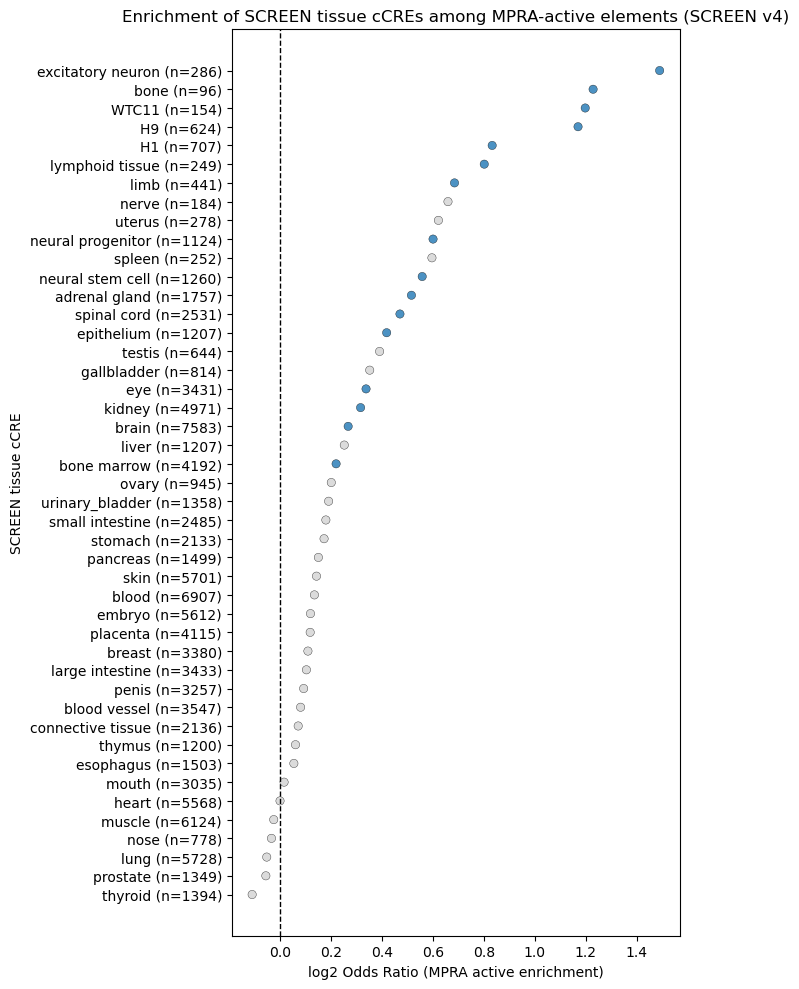

In [19]:
def compute_screen_enrichment(df, screen_cols, activity_col="significant_region_NGN2"):
    """Fisher-exact enrichment of MPRA activity for each SCREEN tissue annotation, FDR-corrected."""
    results = []
    for tissue, col in screen_cols.items():
        a = ((df[col]) & (df[activity_col])).sum()
        b = ((df[col]) & (~df[activity_col])).sum()
        c = ((~df[col]) & (df[activity_col])).sum()
        d = ((~df[col]) & (~df[activity_col])).sum()
        if min(a, b, c, d) == 0:
            or_val, pval = np.nan, np.nan
        else:
            or_val, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        results.append(
            {"tissue": tissue, "odds_ratio": or_val, "p_value": pval, "n_screen_overlap": a + b, "n_active_overlap": a, "n_total": a + b + c + d}
        )
    result_df = pd.DataFrame(results)
    mask = result_df["p_value"].notna()
    result_df.loc[mask, "p_adj_fdr"] = multipletests(result_df.loc[mask, "p_value"], method="fdr_bh")[1]
    return result_df.sort_values("odds_ratio", ascending=False)


df_v4_screen = readout_tested_ref_df.loc[readout_tested_ref_df["screen_v4_annotation"]].copy()

enrichment_df = compute_screen_enrichment(df_v4_screen, screen_cols_all_cell_types)
enrichment_df["log2_OR"] = np.log2(enrichment_df["odds_ratio"]).replace([np.inf, -np.inf], np.nan)
n_active_total = df_v4_screen["significant_region_NGN2"].sum()

enrichment_df["sensitivity"] = enrichment_df["n_active_overlap"] / n_active_total

enrichment_df_plot = enrichment_df.query("n_screen_overlap >= 20").sort_values("log2_OR")
enrichment_df_plot["y_label"] = enrichment_df_plot["tissue"] + " (n=" + enrichment_df_plot["n_screen_overlap"].astype(str) + ")"

plt.figure(figsize=(7, 10))
plt.scatter(
    enrichment_df_plot["log2_OR"], enrichment_df_plot["y_label"],
    c=np.where(enrichment_df_plot["p_adj_fdr"] < 0.05, "#1f77b4", "lightgray"),
    alpha=0.8, edgecolor="black", linewidth=0.3,
)
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.xlabel("log2 Odds Ratio (MPRA active enrichment)")
plt.ylabel("SCREEN tissue cCRE")
plt.title("Enrichment of SCREEN tissue cCREs among MPRA-active elements (SCREEN v4)")
plt.tight_layout()
plt.show()

In [20]:
plot_df = enrichment_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["log2_OR", "sensitivity"]
)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


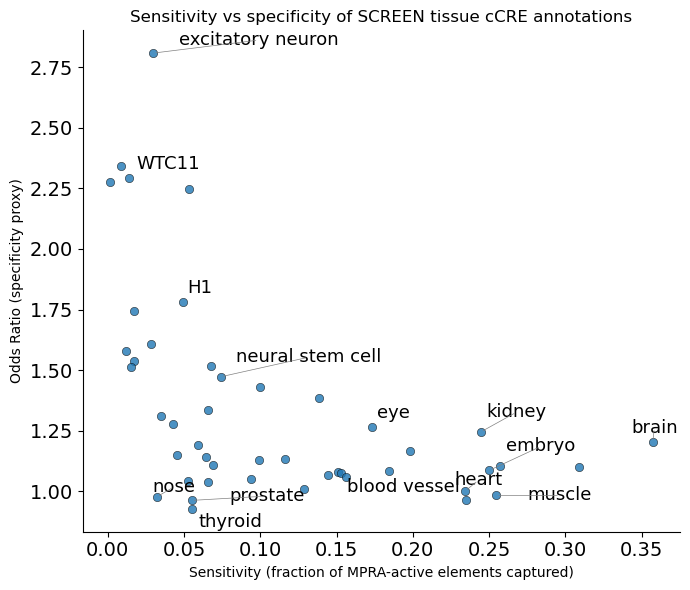

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.style
import matplotlib as mpl
from adjustText import adjust_text

mpl.style.use('default')

plt.figure(figsize=(7, 6))
plt.scatter(
    plot_df["sensitivity"],
    plot_df["odds_ratio"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
)

# x-tick, y-tick fontsize
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel("Sensitivity (fraction of MPRA-active elements captured)")
plt.ylabel("Odds Ratio (specificity proxy)")
plt.title("Sensitivity vs specificity of SCREEN tissue cCRE annotations")

# Collect annotation texts for adjustText
selected_tissues = [
    "brain", "excitatory neuron", "muscle", "heart", "WTC11", "embryo",
    "kidney", "eye", "neural stem cell", "blood vessel", "nose", "H1",
    "thyroid", "prostate"
]

texts = []
for _, row in plot_df.iterrows():
    if row["tissue"] in selected_tissues:
        texts.append(
            plt.text(
                row["sensitivity"],
                row["odds_ratio"],
                row["tissue"],
                fontsize=13,
                alpha=1,
            )
        )

# Automatically adjust text positions to avoid overlaps
adjust_text(
    texts,
    x=plot_df["sensitivity"].values,
    y=plot_df["odds_ratio"].values,
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
    force_points=(0.5, 0.5),
    expand=(1.2, 1.4),
)

plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.tight_layout()
if writing:
    base_figure_dir = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/element_activity"
    output_path = os.path.join(base_figure_dir, "sensitivity_specificity_for_SCREEN_tissues_subset.png")
    output_path_svg = output_path.rsplit(".", 1)[0] + ".svg"
    output_path_png = output_path.rsplit(".", 1)[0] + ".png"
    plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
    plt.savefig(output_path_png, dpi=300, bbox_inches="tight")
plt.show()

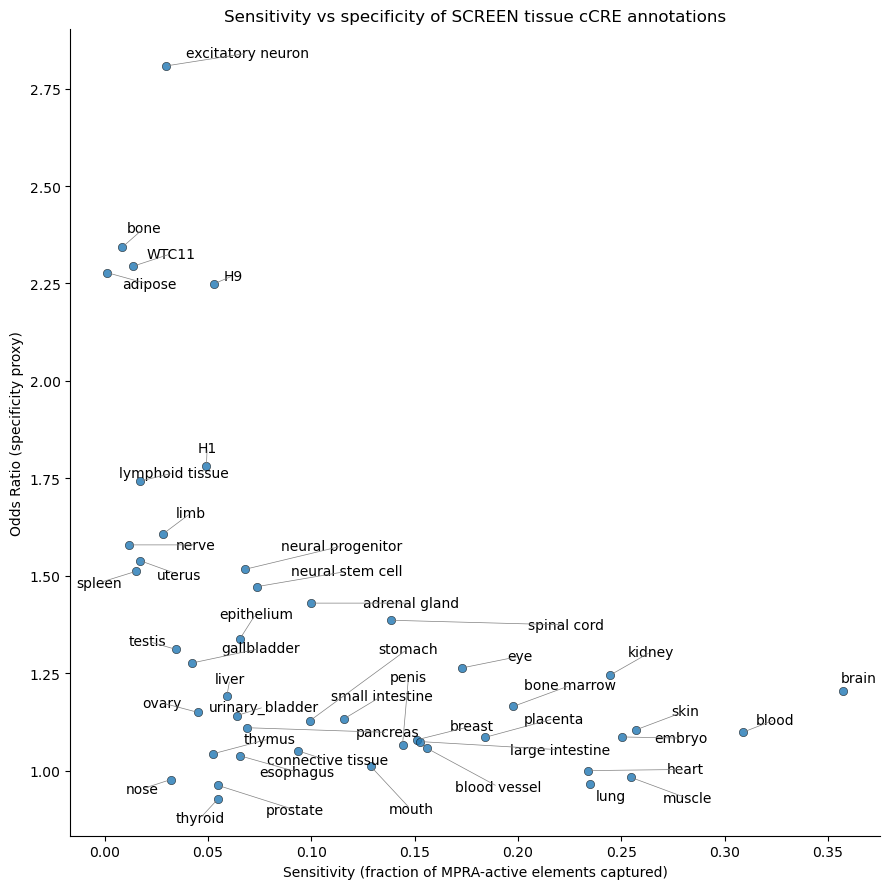

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.style
import matplotlib as mpl
from adjustText import adjust_text

mpl.style.use('default')

plt.figure(figsize=(9, 9))
plt.scatter(
    plot_df["sensitivity"],
    plot_df["odds_ratio"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
)

plt.xlabel("Sensitivity (fraction of MPRA-active elements captured)")
plt.ylabel("Odds Ratio (specificity proxy)")
plt.title("Sensitivity vs specificity of SCREEN tissue cCRE annotations")

# Collect annotation texts for adjustText
selected_tissues = [
    "brain", "excitatory neuron", "muscle", "heart", "WTC11", "embryo",
    "kidney", "eye", "neural stem cell", "blood vessel", "nose", "H1",
    "thyroid", "prostate"
]

texts = []
for _, row in plot_df.iterrows():
    texts.append(
            plt.text(
                row["sensitivity"],
                row["odds_ratio"],
                row["tissue"],
                fontsize=10,
                alpha=1,
            )
        )

# Automatically adjust text positions to avoid overlaps
adjust_text(
    texts,
    x=plot_df["sensitivity"].values,
    y=plot_df["odds_ratio"].values,
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
    force_points=(3),
    expand=(1.5, 1.5),
)

plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.tight_layout()

if writing:
    base_figure_dir = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/element_activity"
    output_path = os.path.join(base_figure_dir, "sensitivity_specificity_for_SCREEN_tissues.png")
    output_path_svg = output_path.rsplit(".", 1)[0] + ".svg"
    output_path_png = output_path.rsplit(".", 1)[0] + ".png"
    plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
    plt.savefig(output_path_png, dpi=300, bbox_inches="tight")
plt.show()

### Tissue annotation breadth and exclusivity of active elements
`active_elements_df` = the significantly active subset. `tissue_cols` = every
`is_*_SCREEN_cCRE` flag, excluding the combined/model-system columns.

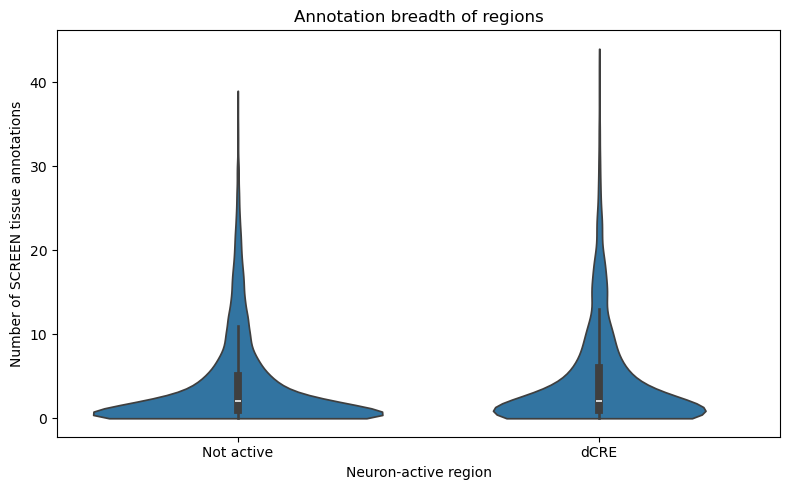

Median dCRE: 2.0
Median non-active: 2.0
Mann-Whitney p: 0.1271092895226725
Cliff's delta: 0.021924856534457273


/tmp/ipykernel_208004/1110494665.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([breadth_non, breadth_dcre], labels=["Not active", "dCRE"], notch=True, showfliers=False)


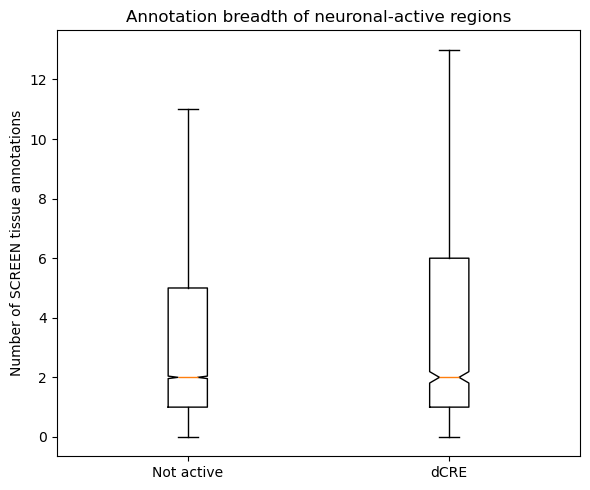

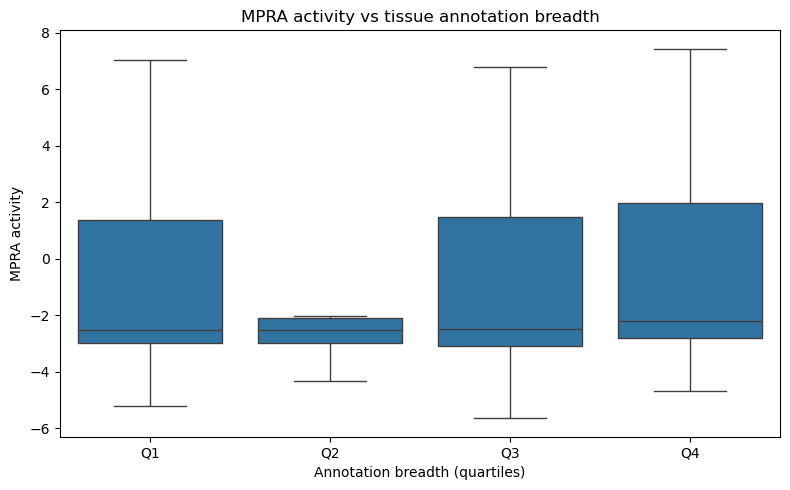

In [23]:
active_elements_df = readout_tested_ref_df.loc[readout_tested_ref_df["significant_region_NGN2"]].copy()

_exclude_from_tissue_cols = {
    "is_all_CRE", "screen_v4_annotation", "is_onlyv3_SCREEN_cCRE", "is_brain_SCREEN_cCRE",
    "is_NPC_SCREEN_cCRE", "is_excitatory_neuron_SCREEN_cCRE", "is_npc_or_excitatory_NSC_SCREEN_cre",
}
tissue_cols = [
    c for c in readout_tested_ref_df.columns
    if c.startswith("is_") and c.endswith("_SCREEN_cCRE") and c not in _exclude_from_tissue_cols
]

readout_tested_ref_df["n_tissues"] = readout_tested_ref_df[tissue_cols].sum(axis=1)
df_dcre = readout_tested_ref_df.loc[readout_tested_ref_df["significant_region_NGN2"]].copy()

plt.figure(figsize=(8, 5))
sns.violinplot(data=readout_tested_ref_df, x="significant_region_NGN2", y="n_tissues", cut=0)
plt.xlabel("Neuron-active region")
plt.ylabel("Number of SCREEN tissue annotations")
plt.title("Annotation breadth of regions")
plt.xticks([0, 1], ["Not active", "dCRE"])
plt.tight_layout()
plt.show()

breadth_dcre = readout_tested_ref_df.loc[readout_tested_ref_df["significant_region_NGN2"], "n_tissues"]
breadth_non = readout_tested_ref_df.loc[~readout_tested_ref_df["significant_region_NGN2"], "n_tissues"]
stat, p = mannwhitneyu(breadth_dcre, breadth_non, alternative="two-sided")


def cliffs_delta(x, y):
    greater = sum(np.sum(xi > y) for xi in x)
    lower = sum(np.sum(xi < y) for xi in x)
    return (greater - lower) / (len(x) * len(y))


delta = cliffs_delta(breadth_dcre.values, breadth_non.values)
print("Median dCRE:", np.median(breadth_dcre))
print("Median non-active:", np.median(breadth_non))
print("Mann-Whitney p:", p)
print("Cliff's delta:", delta)

plt.figure(figsize=(6, 5))
plt.boxplot([breadth_non, breadth_dcre], labels=["Not active", "dCRE"], notch=True, showfliers=False)
plt.ylabel("Number of SCREEN tissue annotations")
plt.title("Annotation breadth of neuronal-active regions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_dcre, x=pd.qcut(df_dcre["n_tissues"], 4, labels=["Q1", "Q2", "Q3", "Q4"]),
    y="normalized_activity_NGN2", showfliers=False,
)
plt.xlabel("Annotation breadth (quartiles)")
plt.ylabel("MPRA activity")
plt.title("MPRA activity vs tissue annotation breadth")
plt.tight_layout()
plt.show()

In [24]:
def pretty_tissue(col):
    """'is_blood_vessel_SCREEN_cCRE' -> 'blood vessel'."""
    t = re.sub(r"^is_", "", col)
    t = re.sub(r"_SCREEN_cCRE$", "", t)
    return t.replace("_", " ")


dev_like_cols = [c for c in ["is_embryo_SCREEN_cCRE", "is_H1_SCREEN_cCRE", "is_H9_SCREEN_cCRE",
                              "is_neural_stem_SCREEN_cCRE", "is_NPC_SCREEN_cCRE"] if c in readout_tested_ref_df.columns]


def compute_dev_like_enrichment(df, fg_mask, bg_mask, label):
    """Fisher-exact enrichment of 'developmental-like' SCREEN annotation (embryo/H1/H9/neural stem/NPC)."""
    df = df.copy()
    df["is_dev_like"] = df[dev_like_cols].any(axis=1)
    fg_dev, fg_not = (fg_mask & df["is_dev_like"]).sum(), (fg_mask & ~df["is_dev_like"]).sum()
    bg_not_fg = bg_mask & ~fg_mask
    bg_dev, bg_not = (bg_not_fg & df["is_dev_like"]).sum(), (bg_not_fg & ~df["is_dev_like"]).sum()
    OR_dev, p_dev = fisher_exact([[fg_dev, fg_not], [bg_dev, bg_not]], alternative="two-sided")
    print(f"\n=== Dev-like enrichment: {label} ===")
    print(f"Foreground dev-like: {int(fg_dev)}/{int(fg_mask.sum())} = {fg_dev / fg_mask.sum() if fg_mask.sum() else 'N/A'}")
    print(f"Background dev-like: {int(bg_dev)}/{int(bg_not_fg.sum())} = {bg_dev / bg_not_fg.sum() if bg_not_fg.sum() else 'N/A'}")
    print(f"Fisher OR: {OR_dev}, p={p_dev}")
    return OR_dev, p_dev



In [25]:
# Variant A: non-brain dCREs vs. non-brain non-dCREs (both with readout)
is_dcre = readout_tested_ref_df["significant_region_NGN2"].astype(bool)
is_non_brain = ~readout_tested_ref_df["is_brain_SCREEN_cCRE"].astype(bool)
fg_a = is_dcre & is_non_brain
bg_a = ~is_dcre & is_non_brain
compute_dev_like_enrichment(readout_tested_ref_df, fg_a, bg_a, "non-brain dCREs vs non-brain non-dCREs")


=== Dev-like enrichment: non-brain dCREs vs non-brain non-dCREs ===
Foreground dev-like: 192/1108 = 0.17328519855595667
Background dev-like: 2724/15819 = 0.17219798975915038
Fisher OR: 1.0076371121328127, p=0.9344058410861946


(np.float64(1.0076371121328127), np.float64(0.9344058410861946))

In [26]:
# Variant B: non-brain dCREs vs. all active elements (any tissue)
is_dcre_active = active_elements_df["significant_region_NGN2"].astype(bool)
is_non_brain_active = ~active_elements_df["is_brain_SCREEN_cCRE"].astype(bool)
fg_b = is_dcre_active & is_non_brain_active
bg_b = pd.Series(True, index=active_elements_df.index)
compute_dev_like_enrichment(active_elements_df, fg_b, bg_b, "non-brain dCREs vs all active elements")


=== Dev-like enrichment: non-brain dCREs vs all active elements ===
Foreground dev-like: 192/1108 = 0.17328519855595667
Background dev-like: 260/580 = 0.4482758620689655
Fisher OR: 0.2579778300302318, p=1.1405513776928008e-32


(np.float64(0.2579778300302318), np.float64(1.1405513776928008e-32))

Skipping is_bone_SCREEN_cCRE due to low number of annotated regions (14)
Skipping is_nerve_SCREEN_cCRE due to low number of annotated regions (19)
Skipping is_vagina_SCREEN_cCRE due to low number of annotated regions (0)
Skipping is_urinary_bladder_acety_methy_SCREEN_cCRE due to low number of annotated regions (0)
Skipping is_parathyroid_adenoma_SCREEN_cCRE due to low number of annotated regions (0)
Skipping is_adipose_SCREEN_cCRE due to low number of annotated regions (2)


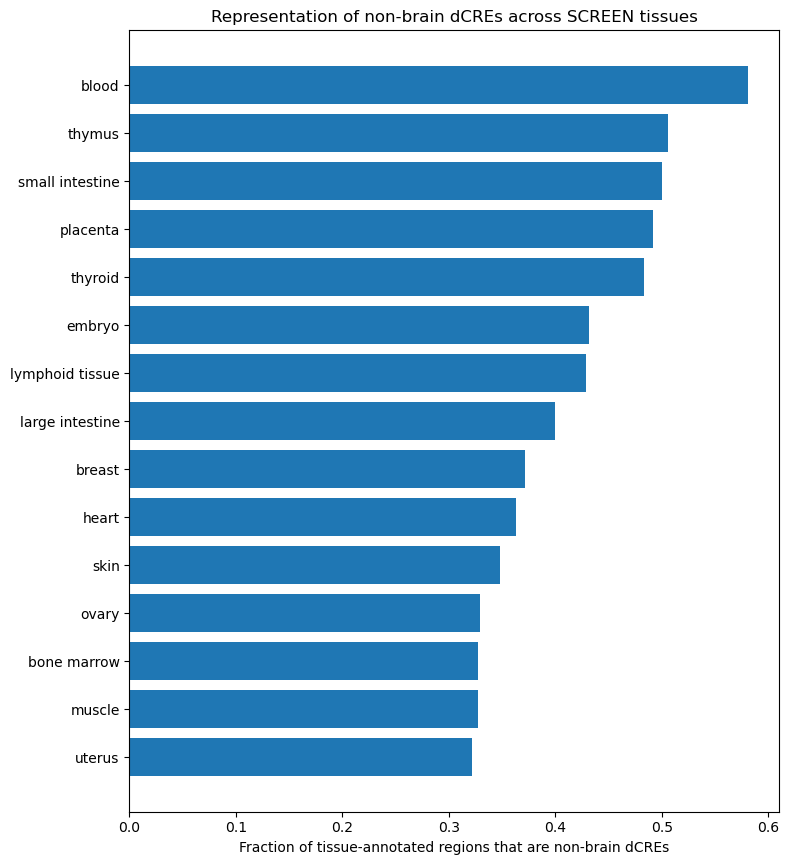

In [27]:
NGN2_cre_screen_tissue_df = active_elements_df.copy()
is_dcre = NGN2_cre_screen_tissue_df["significant_region_NGN2"].astype(bool)
is_non_brain = ~NGN2_cre_screen_tissue_df["is_brain_SCREEN_cCRE"].astype(bool)
fg = is_dcre & is_non_brain

rows = []
for col in tissue_cols:
    annot = NGN2_cre_screen_tissue_df[col].astype(bool)
    total_in_tissue = annot.sum()
    if total_in_tissue < 20:
        print(f"Skipping {col} due to low number of annotated regions ({total_in_tissue})")
        continue
    nonbrain_dcre_in_tissue = (fg & annot).sum()
    rows.append(
        {
            "tissue": pretty_tissue(col), "total_regions_in_tissue": int(total_in_tissue),
            "nonbrain_dcre_in_tissue": int(nonbrain_dcre_in_tissue),
            "representation_fraction": nonbrain_dcre_in_tissue / total_in_tissue,
        }
    )
rep_df = pd.DataFrame(rows).sort_values("representation_fraction", ascending=False)

topN = 15
plot_df = rep_df.head(topN).sort_values("representation_fraction")
plt.figure(figsize=(8, 0.45 * len(plot_df) + 2))
plt.barh(plot_df["tissue"], plot_df["representation_fraction"])
plt.xlabel("Fraction of tissue-annotated regions that are non-brain dCREs")
plt.title("Representation of non-brain dCREs across SCREEN tissues")
plt.tight_layout()
plt.show()

In [28]:
def find_exclusive_tissues(df, screen_columns):
    """Tissues where annotated regions never overlap any other tissue in screen_columns."""
    df = df.copy()
    df[screen_columns] = df[screen_columns].astype(bool)
    exclusive = []
    for tissue_col in screen_columns:
        tissue_rows = df[df[tissue_col]]
        if tissue_rows.empty:
            continue
        other_cols = [c for c in screen_columns if c != tissue_col]
        if not tissue_rows[other_cols].any(axis=1).any():
            exclusive.append(tissue_col)
    return exclusive


exclusive_tissues = find_exclusive_tissues(active_elements_df, list(screen_cols_all_tissue_types.values()))
print(f"Number of exclusive tissues: {len(exclusive_tissues)}")
print(exclusive_tissues)

for name, col in screen_cols_all_tissue_types.items():
    n_overlap = active_elements_df[col].sum()
    if n_overlap < 20 or n_overlap > 200:
        print(f"{name}: {n_overlap}")

Number of exclusive tissues: 0
[]
adipose: 2
blood: 501
blood vessel: 253
bone: 14
bone marrow: 321
brain: 580
breast: 245
embryo: 406
eye: 281
heart: 380
kidney: 397
large intestine: 248
lung: 381
mouth: 209
muscle: 413
nerve: 19
penis: 234
placenta: 299
skin: 417
spinal cord: 225
vagina: 0


In [29]:
def plot_screen_upset(df, screen_cols, neuronal_cols=("is_brain_SCREEN_cCRE",), **upset_kwargs):
    """Binary SCREEN-annotation matrix -> sensitivity print + UpSet plot."""
    screen_mat = df[list(screen_cols)].astype(bool)
    df = df.copy()
    df["SCREEN_neuronal"] = df[list(neuronal_cols)].any(axis=1)
    sensitivity = df["SCREEN_neuronal"].mean()
    print(f"Only {sensitivity:.2%} of the significantly active elements are annotated as neuronal SCREEN cCREs")
    upset_data = from_indicators(screen_mat.columns, screen_mat)
    UpSet(upset_data, show_counts=True, **upset_kwargs).plot()
    plt.show()

In [ ]:
# NB: the two "cell-type only" UpSet plots use `screen_cols` (9 entries), not
# `screen_cols_all_cell_types` (49 entries) — matching the original notebook's actual
# scoping for these two specific plots.
plot_screen_upset(active_elements_df, screen_cols.values(), min_subset_size=8)
plot_screen_upset(active_elements_df, screen_cols_all_tissue_types.values(), min_subset_size=8)
plot_screen_upset(active_elements_df, screen_cols_all_tissue_types.values(), min_degree=2)

active_elements_non_brain_df = active_elements_df.loc[~active_elements_df["is_brain_SCREEN_cCRE"]].copy()
screen_mat_not_brain = active_elements_non_brain_df[list(screen_cols_all_tissue_types.values())].astype(bool)
upset_data = from_indicators(screen_mat_not_brain.columns, screen_mat_not_brain)
UpSet(upset_data, show_counts=True, max_degree=1, sort_by="cardinality").plot()
plt.show()

active_elements_df_v4_screen = active_elements_df.loc[active_elements_df["screen_v4_annotation"]].copy()
plot_screen_upset(active_elements_df_v4_screen, screen_cols.values(), min_subset_size=8)
plot_screen_upset(active_elements_df_v4_screen, screen_cols_all_tissue_types.values(), min_subset_size=8)

In [ ]:
# screen_big_subset_non_brain_cols: the 7 largest non-brain tissue overlaps (kept for
# reference, as in the original notebook); the UpSet plot below was actually drawn from
# a 5-entry reduced version (lung/bone_marrow dropped) even though the manually-read-off
# summary numbers further down cover all 7 — reproduced as in the original.
screen_big_subset_non_brain_cols = {
    "blood": "is_blood_SCREEN_cCRE",
    "embryo": "is_embryo_SCREEN_cCRE",
    "placenta": "is_placenta_SCREEN_cCRE",
    "heart": "is_heart_SCREEN_cCRE",
    "kidney": "is_kidney_SCREEN_cCRE",
    "lung": "is_lung_SCREEN_cCRE",
    "bone_marrow": "is_bone_marrow_SCREEN_cCRE",
}
screen_big_subset_non_brain_cols_redu = {
    "blood": "is_blood_SCREEN_cCRE",
    "embryo": "is_embryo_SCREEN_cCRE",
    "placenta": "is_placenta_SCREEN_cCRE",
    "heart": "is_heart_SCREEN_cCRE",
    "kidney": "is_kidney_SCREEN_cCRE",
}
screen_mat_not_brain_big = active_elements_non_brain_df[list(screen_big_subset_non_brain_cols_redu.values())].astype(bool)
upset_data = from_indicators(screen_mat_not_brain_big.columns, screen_mat_not_brain_big)
UpSet(upset_data, show_counts=True, min_subset_size=8).plot()
plt.show()

In [32]:
# manually-read-off numbers from the non-brain-exclusive UpSet plot above (kept as in
# the original notebook, since these were transcribed by eye rather than computed)
n_blood, n_embryo, n_placenta, n_heart, n_kidney, n_lung, n_bone_marrow = 291, 175, 145, 135, 125, 117, 105
overall_active_elements_not_brain = 1108
for not_covered in (498, 542):
    print(f"\nNot covered %: {not_covered / overall_active_elements_not_brain:.2%}")
    print(f"Covered %: {(overall_active_elements_not_brain - not_covered) / overall_active_elements_not_brain:.2%}")
print("Blood %: ", f"{n_blood/overall_active_elements_not_brain:.2%}")
print("Embryo %: ", f"{n_embryo/overall_active_elements_not_brain:.2%}")
print("Placenta %: ", f"{n_placenta/overall_active_elements_not_brain:.2%}")
print("Heart %: ", f"{n_heart/overall_active_elements_not_brain:.2%}")
print("Kidney %: ", f"{n_kidney/overall_active_elements_not_brain:.2%}")
print("Lung %: ", f"{n_lung/overall_active_elements_not_brain:.2%}")
print("Bone marrow %: ", f"{n_bone_marrow/overall_active_elements_not_brain:.2%}")


Not covered %: 44.95%
Covered %: 55.05%

Not covered %: 48.92%
Covered %: 51.08%
Blood %:  26.26%
Embryo %:  15.79%
Placenta %:  13.09%
Heart %:  12.18%
Kidney %:  11.28%
Lung %:  10.56%
Bone marrow %:  9.48%


### Fraction of regions active in NGN2 neurons per tissue, split by direction

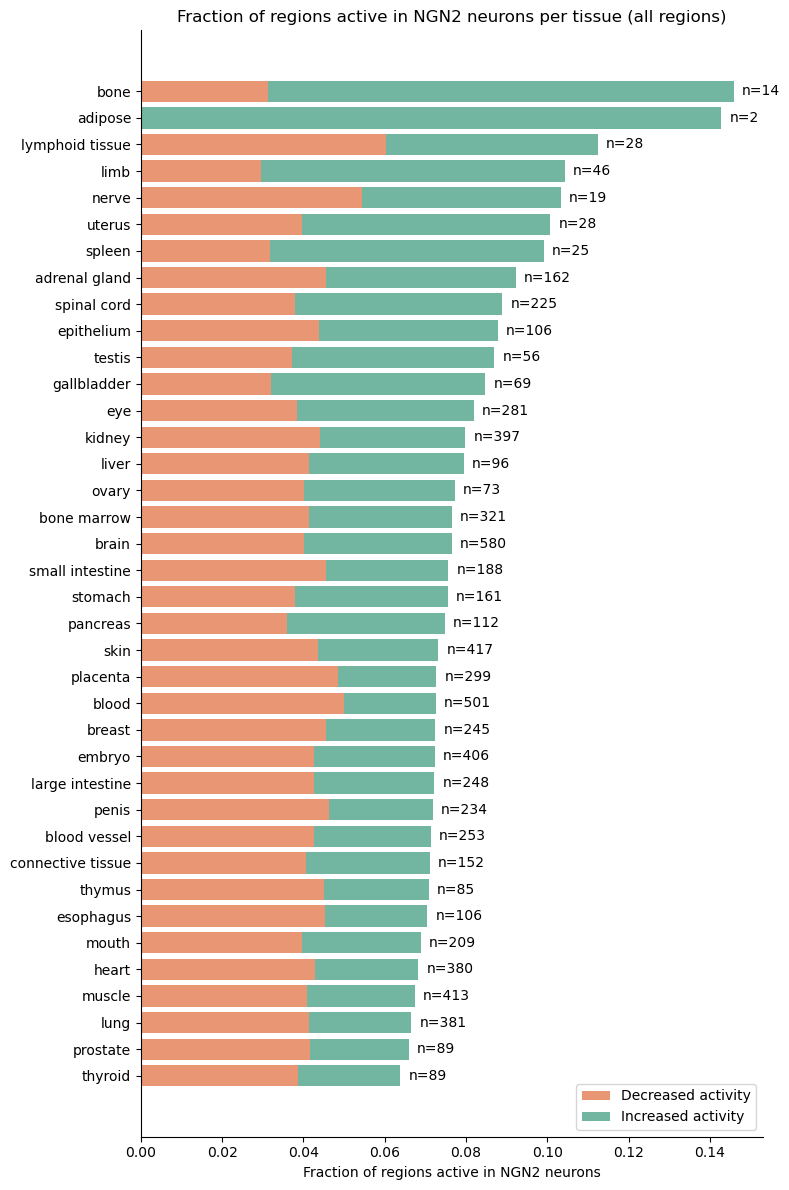

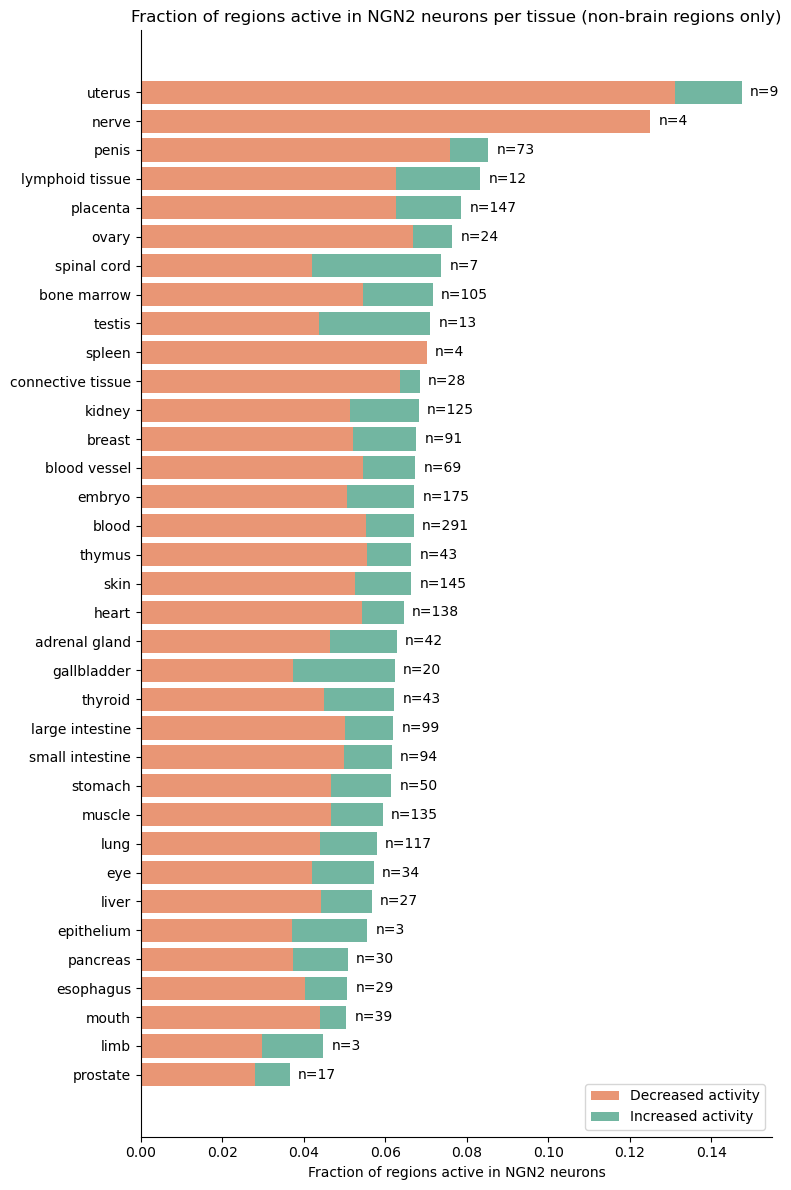

In [33]:
def plot_fraction_active_per_tissue(df, screen_cols, title):
    """Horizontal stacked bar chart of the fraction of regions active per tissue, split by direction."""
    tissue_cols_ = list(screen_cols.values())
    tissue_names = list(screen_cols.keys())
    df_sig = df.loc[df["significant_region_NGN2"]]

    total_counts = df[tissue_cols_].sum()
    pos_counts = df_sig.loc[df_sig["normalized_activity_NGN2"] > 0, tissue_cols_].sum()
    neg_counts = df_sig.loc[df_sig["normalized_activity_NGN2"] < 0, tissue_cols_].sum()

    plot_df = pd.DataFrame(
        {
            "pos": pos_counts / total_counts, "neg": neg_counts / total_counts,
            "total_dcre": pos_counts + neg_counts, "tissue_names": tissue_names,
        }
    )
    plot_df["total_fraction"] = plot_df["pos"] + plot_df["neg"]
    plot_df = plot_df.loc[plot_df["total_fraction"] > 0].sort_values("total_fraction")

    y = np.arange(len(plot_df))
    plt.figure(figsize=(8, 12))
    plt.barh(y, plot_df["neg"], color="#E99675", label="Decreased activity")
    plt.barh(y, plot_df["pos"], left=plot_df["neg"], color="#72B6A1", label="Increased activity")
    for i, total in enumerate(plot_df["total_dcre"]):
        plt.text(plot_df["neg"].iloc[i] + plot_df["pos"].iloc[i] + 0.002, i, f"n={int(total)}", va="center")
    plt.yticks(y, plot_df["tissue_names"])
    plt.xlabel("Fraction of regions active in NGN2 neurons")
    plt.title(title)
    sns.despine(right=True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return plot_df


_ = plot_fraction_active_per_tissue(
    readout_tested_ref_df, screen_cols_all_tissue_types,
    "Fraction of regions active in NGN2 neurons per tissue (all regions)",
)
_ = plot_fraction_active_per_tissue(
    readout_tested_ref_df.loc[~readout_tested_ref_df["is_brain_SCREEN_cCRE"]], screen_cols_all_tissue_types,
    "Fraction of regions active in NGN2 neurons per tissue (non-brain regions only)",
)

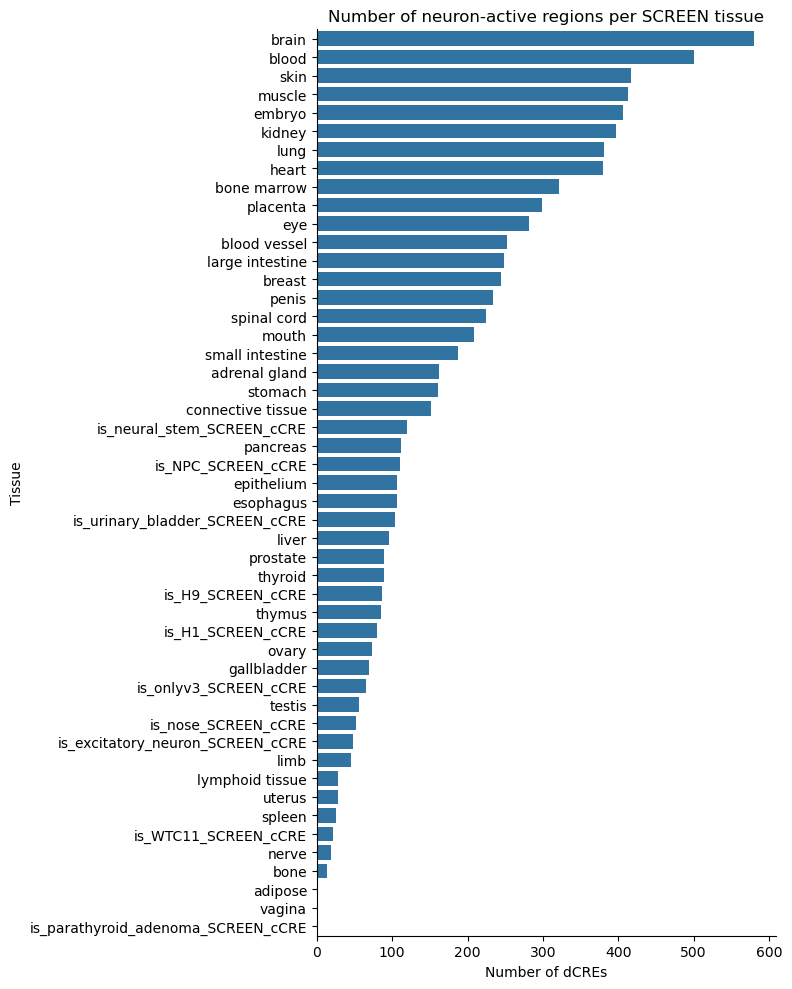

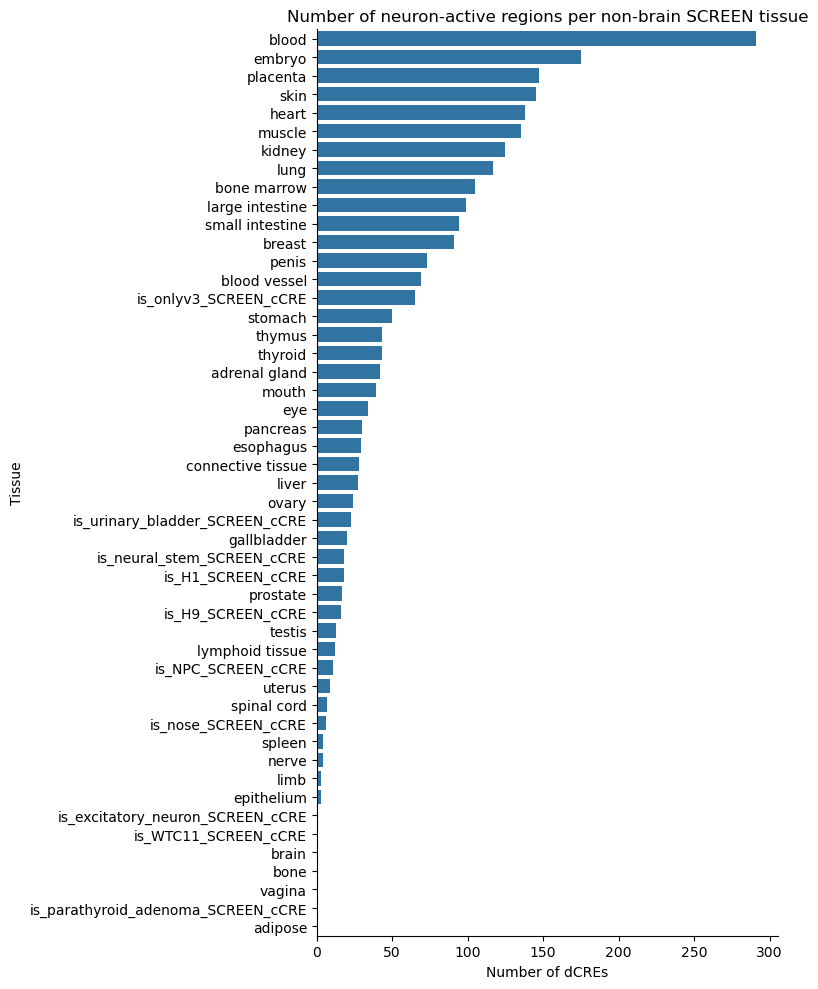

blood                                 291
embryo                                175
placenta                              147
skin                                  145
heart                                 138
muscle                                135
kidney                                125
lung                                  117
bone marrow                           105
large intestine                        99
small intestine                        94
breast                                 91
penis                                  73
blood vessel                           69
is_onlyv3_SCREEN_cCRE                  65
stomach                                50
thymus                                 43
thyroid                                43
adrenal gland                          42
mouth                                  39
eye                                    34
pancreas                               30
esophagus                              29
connective tissue                 

In [34]:
col_to_tissue = {v: k for k, v in screen_cols_all_tissue_types.items()}
dcre_counts = (
    df_dcre[list(screen_cols_all_cell_types.values())].sum().rename(index=col_to_tissue).sort_values(ascending=False)
)
plt.figure(figsize=(8, 10))
sns.barplot(x=dcre_counts.values, y=dcre_counts.index)
plt.xlabel("Number of dCREs")
plt.ylabel("Tissue")
plt.title("Number of neuron-active regions per SCREEN tissue")
sns.despine()
plt.tight_layout()
plt.show()

non_brain_dCREs = active_elements_df.loc[~active_elements_df["is_brain_SCREEN_cCRE"]].copy()
non_brain_dcre_counts = (
    non_brain_dCREs[list(screen_cols_all_cell_types.values())].sum().rename(index=col_to_tissue).sort_values(ascending=False)
)
plt.figure(figsize=(8, 10))
sns.barplot(x=non_brain_dcre_counts.values, y=non_brain_dcre_counts.index)
plt.xlabel("Number of dCREs")
plt.ylabel("Tissue")
plt.title("Number of neuron-active regions per non-brain SCREEN tissue")
sns.despine()
plt.tight_layout()
plt.show()
print(non_brain_dcre_counts.to_string())

### Element activity distribution

In [35]:
readout_tested_ref_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,is_vagina_SCREEN_cCRE,is_urinary_bladder_dnase_SCREEN_cCRE,is_urinary_bladder_acety_methy_SCREEN_cCRE,is_parathyroid_adenoma_SCREEN_cCRE,is_adipose_SCREEN_cCRE,is_urinary_bladder_SCREEN_cCRE,is_all_CRE,screen_v4_annotation,is_onlyv3_SCREEN_cCRE,n_tissues
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,False,False,False,False,False,False,True,True,False,0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,False,False,False,False,False,False,True,True,False,0
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,False,False,False,False,False,False,True,True,False,4
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,...,False,False,False,False,False,False,True,True,False,2
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,...,False,False,False,False,False,False,True,True,False,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24505,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466.0,154519736.0,-,...,False,False,False,False,False,False,True,True,False,1
24506,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,...,False,False,False,False,False,False,True,True,False,1
24507,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,False,False,False,False,False,False,True,True,False,0
24508,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,False,False,False,False,False,False,True,True,False,8


In [36]:
readout_tested_ref_df.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN_cCRE_group

In [37]:
readout_tested_ref_df_test = readout_tested_ref_df.copy()

In [38]:
# expression:
readout_tested_ref_df_test["associated_gene_name"] = readout_tested_ref_df_test["gene_name"]

# downloaded here: https://www.proteinatlas.org/humanproteome/brain/data#hpa_brain_regions_rna
hpa_brain_path = "data/rna_brain_region_hpa.tsv"
hpa_brain_df = pd.read_csv(hpa_brain_path, sep="\t")

brain_region_cerebral_cortex_nTPMs = (
    hpa_brain_df.loc[hpa_brain_df["Brain region"] == "cerebral cortex"]
    .groupby("Gene name")["nTPM"]
    .max()
    .reset_index()
)

# rename nTPM => linked_gene_nTPM_cerebral_cortex
brain_region_cerebral_cortex_nTPMs = brain_region_cerebral_cortex_nTPMs.rename(
    columns={"nTPM": "linked_gene_nTPM_cerebral_cortex"}
)


readout_tested_ref_df_test = (
    readout_tested_ref_df_test.merge(
        brain_region_cerebral_cortex_nTPMs,
        left_on="associated_gene_name",
        right_on="Gene name",
        how="left",
    )
).drop(columns=["Gene name"])


# check for the NA genes:
na_genes = readout_tested_ref_df_test.loc[
    readout_tested_ref_df_test["linked_gene_nTPM_cerebral_cortex"].isna(),
    "associated_gene_name",
].unique()
print(f"Number of associated genes with NA cerebral cortex expression: {len(na_genes)}")
print(f"Associated genes with NA cerebral cortex expression: {na_genes}")

Number of associated genes with NA cerebral cortex expression: 3
Associated genes with NA cerebral cortex expression: ['LINC01033' 'LINC01626' 'LINC01583']


In [39]:
def get_neuron_screen_cres_around_neuronal_expressed_genes(row, screen_neuron_col="is_glutaNeuron_SCREEN_cCRE", nTPM_neuron_col="linked_gene_nTPM_cerebral_cortex", expression_threshold=3, without_screen_cre_consideration=False):
    is_neuron_screen_cre = row[screen_neuron_col] if not without_screen_cre_consideration else True
    gene_expression = row[nTPM_neuron_col]
    is_expressed_in_neuron = gene_expression >= expression_threshold
    # check if is_neuron_screen_cre is True and is_expressed_in_neuron is True
    verbose=False
    if verbose:
        print(f"Row: {row['name']}")
        print(f"  is_neuron_screen_cre: {is_neuron_screen_cre}, type: {type(is_neuron_screen_cre)}")
        print(f"  gene_expression (nTPM): {gene_expression}")
        print(f"  is_expressed_in_neuron: {is_expressed_in_neuron}, type: {type(is_expressed_in_neuron)}")
    if is_neuron_screen_cre and is_expressed_in_neuron:
        return True
    return False

def get_cardiac_screen_cres_around_gene_not_expressed_in_neurons(row, screen_heart_col="is_heart_SCREEN_cCRE", nTPM_neuron_col="linked_gene_nTPM_cerebral_cortex", expression_threshold=1, without_screen_cre_consideration=False):
    is_heart_screen_cre = row[screen_heart_col] if not without_screen_cre_consideration else True
    gene_expression = row[nTPM_neuron_col]
    is_not_expressed_in_neuron = gene_expression < expression_threshold
    # check if is_heart_screen_cre is True and is_not_expressed_in_neuron is True
    verbose=False
    if verbose:
        print(f"Row: {row['name']}")
        print(f"  is_heart_screen_cre: {is_heart_screen_cre}, type: {type(is_heart_screen_cre)}")
        print(f"  gene_expression (nTPM): {gene_expression}")
        print(f"  is_not_expressed_in_neuron: {is_not_expressed_in_neuron}, type: {type(is_not_expressed_in_neuron)}")
    if is_heart_screen_cre and is_not_expressed_in_neuron:
        return True
    return False
# activity of screen regions excitatory neurons around expressed genes in neurons

# activity of heart screen regions around likely not expressed genes in neurons (around cardiac genes)

In [40]:
readout_tested_ref_df_test[
    "is_neuronal_screen_around_expressed_neuronal_gene"
] = readout_tested_ref_df_test.apply(
    lambda row: get_neuron_screen_cres_around_neuronal_expressed_genes(
        row,
        screen_neuron_col="is_excitatory_neuron_SCREEN_cCRE",
        nTPM_neuron_col="linked_gene_nTPM_cerebral_cortex",
        expression_threshold=3,
        without_screen_cre_consideration=False
    ),
    axis=1,
)
readout_tested_ref_df_test[
    "is_cardiac_screen_around_non_expressed_neuronal_gene"
] = readout_tested_ref_df_test.apply(
    lambda row: get_cardiac_screen_cres_around_gene_not_expressed_in_neurons(
        row,
        screen_heart_col="is_heart_SCREEN_cCRE",
        nTPM_neuron_col="linked_gene_nTPM_cerebral_cortex",
        expression_threshold=1,
        without_screen_cre_consideration=False
    ),
    axis=1,
)
readout_tested_ref_df_test[
    "is_around_expressed_neuronal_gene"
] = readout_tested_ref_df_test.apply(
    lambda row: get_neuron_screen_cres_around_neuronal_expressed_genes(
        row,
        screen_neuron_col="is_excitatory_neuron_SCREEN_cCRE",
        nTPM_neuron_col="linked_gene_nTPM_cerebral_cortex",
        expression_threshold=3,
        without_screen_cre_consideration=True
    ),
    axis=1,
)
readout_tested_ref_df_test[
    "is_around_non_expressed_neuronal_gene"
] = readout_tested_ref_df_test.apply(
    lambda row: get_cardiac_screen_cres_around_gene_not_expressed_in_neurons(
        row,
        screen_heart_col="is_heart_SCREEN_cCRE",
        nTPM_neuron_col="linked_gene_nTPM_cerebral_cortex",
        expression_threshold=1,
        without_screen_cre_consideration=True
    ),
    axis=1,
)


In [41]:
readout_tested_ref_df_test["start"] = readout_tested_ref_df_test["start"].astype(int)
readout_tested_ref_df_test["end"] = readout_tested_ref_df_test["end"].astype(int)
readout_tested_ref_df_test["genomic_context"] = (
    readout_tested_ref_df_test
).apply(
    lambda row: f"{row['chr']}:{row['start']}-{row['end']}",
    axis=1,
)
readout_tested_ref_df_test[
    "genomic_context_with_strand"
] = (readout_tested_ref_df_test).apply(
    lambda row: f"{row['chr']}:{row['start']}-{row['end']}({row['strand']})",
    axis=1,
)
readout_tested_ref_df_test

n_unique_screen_ids = readout_tested_ref_df_test["SCREEN_ID"].nunique()
print(f"Number of unique SCREEN_IDs in the dataset: {n_unique_screen_ids}")
n_unique_regions = readout_tested_ref_df_test[
    "genomic_context"
].nunique()
print(f"Number of unique regions in the dataset: {n_unique_regions}")

Number of unique SCREEN_IDs in the dataset: 24358
Number of unique regions in the dataset: 24358


In [42]:
readout_tested_ref_df_test.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN_cCRE_group

In [43]:
around_neuronal_genes = readout_tested_ref_df_test.loc[
    readout_tested_ref_df_test[
        "is_around_expressed_neuronal_gene"
    ]
].copy()
around_neuronal_genes["element_activity_plot_label"] = (
    "cCREs neuronal genes (nTPM>3)"
)
neuronal_cres_around_neuronal_genes = readout_tested_ref_df_test.loc[
    readout_tested_ref_df_test[
        "is_neuronal_screen_around_expressed_neuronal_gene"
    ]
].copy()
neuronal_cres_around_neuronal_genes["element_activity_plot_label"] = (
    "Neuronal cCREs around neuronal genes (nTPM>3)"
)

around_not_expressed_genes = readout_tested_ref_df_test.loc[readout_tested_ref_df_test[
    "is_around_non_expressed_neuronal_gene"
]].copy()
around_not_expressed_genes["element_activity_plot_label"] = "cCREs non-neuronal genes (nTPM<1)"
cardiac_cres_around_not_expressed_genes = readout_tested_ref_df_test.loc[readout_tested_ref_df_test[
    "is_cardiac_screen_around_non_expressed_neuronal_gene"
]].copy()
cardiac_cres_around_not_expressed_genes["element_activity_plot_label"] = "Cardiac cCREs around non-neuronal genes (nTPM<1)"

In [44]:
readout_tested_ref_df_test.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN_cCRE_group

In [45]:
# read in the variants:
reading = True
if reading:
    input_variant_effect_metadata_path = "data/2602_NGN2_MPRA_variant_effect_with_metadata.tsv.gz"
    variant_effect_df = pd.read_csv(input_variant_effect_metadata_path, sep="\t")

    # example row
    example_row = variant_effect_df.iloc[0]

    # eval list like columns
    list_list_cols = []
    for col in variant_effect_df.columns:
        if (
            example_row[col]
            and isinstance(example_row[col], str)
            and "[" in example_row[col]
        ):
            list_list_cols.append(col)

    for col in list_list_cols:
        variant_effect_df[col] = variant_effect_df[col].apply(
            hf.safe_eval
        )


variant_effect_df_reference_id = variant_effect_df["REF"].to_list()
variant_effect_df_alternative_id = variant_effect_df["ALT"].to_list()


def element_based_control_labels(
    row,
    name_col="name",
    reference_list=variant_effect_df_reference_id,
    alternative_list=variant_effect_df_alternative_id,
    split_tested_sequences=False,
    split_negative_neuron_MK_NP=False,
    split_positive_MK_NP_CD=False,
    combine_positive_neuron_MK_NP=True,
):
    """Generate control labels based on genomic context"""
    sequence_name = row[name_col]
    # ALT and REF based on name: contains REF, contains ALT
    if "cardiac_neuro_cava_random" in sequence_name:
        if split_tested_sequences:
            # focus on design so beliefe in REF / ALT
            if ":REF_" in sequence_name:
                return "Tested ref allele"
            elif ":ALT_" in sequence_name:
                return "Tested alt allele"
            else:
                return "Tested region no variant designed"
        else:
            return "Tested sequences"
    # control variants (trust the variant map)
    # scrambled
    if "scramble" in sequence_name.lower():
        return "scrambled control"

    # negative neuro MK + negative neuro NP + Negative neuro CD
    negative_neuron_controls = ["C_negative_neuron_MK", "C_negative_neuron_NP"]
    for control in negative_neuron_controls:
        if control in sequence_name:
            if split_negative_neuron_MK_NP:
                return f"{control}"
            else:
                return "Negative control"

    # positive neuro MK + positive neuro CD + positive neuro MK + positive neuro NP
    positive_neuron_controls = [
        "C_positive_neuron_MK",
        "C_positive_neuron_NP",
        "C_positive_neuron_CD",
    ]
    for control in positive_neuron_controls:
        if control in sequence_name:
            if combine_positive_neuron_MK_NP and not split_positive_MK_NP_CD:
                if "_MK" in sequence_name or "_NP" in sequence_name:
                    return "Positive control"
                else:
                    return f"{control}"
            elif split_positive_MK_NP_CD:
                return f"{control}"
            else:
                return "Positive control"
    # how to handle regions which are combined from two groups? => just take first, because should describe the same sequence
    groups_with_variants = [
        "MK",
        "C_positive_heart_CAD",
        "C_positive_heart_MK",
    ]
    for group in groups_with_variants:
        if group in sequence_name:
            if sequence_name in alternative_list:
                return f"{group} alt allele"
            elif sequence_name in reference_list:
                return f"{group} ref allele"
            else:
                return f"{group} element"

    groups_with_annotation = {
        "GC_Liang": "Neuronal (caQTL/eQTL)",
        "GC_Atrial_fib": "Artrial STARR-Seq allelic effects",
        "GC_Selvarajan": "HepG2 STARR-Seq allelic effects",
        "GC_Mohlke": "Published unpublished allelic effects (Mohlke)",
        "GC_Kircher": "LDLR and SORT1 loci allelic effects (Kircher)",
        "GC_Vista": "Core enhancer mouse embryos (MK)",
        "GC_Hon": "CHD enhancer control (Hon)",
        "GC_Mendelian_variants": "Mendelian disease variants (Pazin)",
        "GC_GABA_Chengyu": "GABAergic control (CD)",
        "GC_Glut_Chengyu": "Glutamatergic control (CD)",
        "GC_Cort_Chengyu": "Cortical cell control (CD)",
    }
    for key, label in groups_with_annotation.items():
        if key in sequence_name:
            return label

    if "GC_DNase" in sequence_name:
        return "DNase elements wrong coordinates"

    if "C_SLEA" in sequence_name:
        return "Synthetic enhancer control"

    other_gc_controls = {}
    for key, label in other_gc_controls.items():
        if key in sequence_name:
            return label

In [46]:
ngn2_mpra_input_path = "data/ngn2_element_activity_metadata_202602_bbmap_only_mpralib095_normalized_bcalm_dna_ge_1.tsv.gz"
reading = True
if reading:
    ngn2_element_activity_df = pd.read_csv(ngn2_mpra_input_path, sep="\t")

    # get example row:
    example_row = ngn2_element_activity_df.iloc[0]

    # eval list like columns
    # get all columns which contain a "[" in the values
    list_list_cols = []
    for col in ngn2_element_activity_df.columns:
        if (
            example_row[col]
            and isinstance(example_row[col], str)
            and "[" in example_row[col]
        ):
            list_list_cols.append(col)

    for col in list_list_cols:
        ngn2_element_activity_df[col] = ngn2_element_activity_df[col].apply(
            hf.safe_eval
        )


ngn2_element_activity_df_with_region = ngn2_element_activity_df.dropna(
    subset=[col_chr, col_start, col_end]
)

ngn2_element_activity_df_with_region_with_readout = (
    ngn2_element_activity_df_with_region.loc[
        ngn2_element_activity_df_with_region["has_readout"]
    ].copy()
)


# ngn2_tested_element_activity_df_with_region_with_readout
ngn2_element_activity_df_with_region_with_readout["element_activity_plot_label"] = (
    ngn2_element_activity_df_with_region_with_readout.apply(
        lambda row: element_based_control_labels(
            row,
            name_col="name",
            reference_list=variant_effect_df_reference_id,
            alternative_list=variant_effect_df_alternative_id,
            split_tested_sequences=False,
            split_positive_MK_NP_CD=False,
        ),
        axis=1,
    )
)
ngn2_element_activity_df_with_region_with_readout[
    "element_activity_plot_label"
].value_counts()



ngn2_element_activity_df_with_region_with_readout["significant_region_NGN2"] = ngn2_element_activity_df_with_region["different_active_to_scrambled"]
ngn2_element_activity_df_with_region_with_readout["effect_direction_NGN2"] = ngn2_element_activity_df_with_region["effect_direction"]


/tmp/ipykernel_208004/4203526944.py:4: DtypeWarning: Columns (4,14) have mixed types. Specify dtype option on import or set low_memory=False.
  ngn2_element_activity_df = pd.read_csv(ngn2_mpra_input_path, sep="\t")


In [47]:
plot_info_columns = ['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'normalized_name', 'logFC',
       'adj.P.Val', 'has_readout_NGN2', 'label',
       'normalized_activity_NGN2', 'genomic_context_with_strand',
       'genomic_context', 'significant_region_NGN2', 'effect_direction_NGN2',
       'element_activity_plot_label']

with_expression_ngn2_element_activity_df = pd.concat(
    [
        around_neuronal_genes[plot_info_columns],
        around_not_expressed_genes[plot_info_columns],
        neuronal_cres_around_neuronal_genes[plot_info_columns],
        cardiac_cres_around_not_expressed_genes[plot_info_columns],
        ngn2_element_activity_df_with_region_with_readout,
    ],
    ignore_index=True,
)

In [48]:
# get the set of regions that has variants defined (contains (:REF_))
screen_ids_with_variants = set(readout_tested_ref_df_test[
    readout_tested_ref_df_test["name"].str.contains(":REF_")
]["SCREEN_ID"].unique())

# check how many regions do not have variants defined (SCREEN_ID)
screen_ids_without_variants_from_name = set(
    readout_tested_ref_df_test[
        ~readout_tested_ref_df_test["name"].str.contains(
            ":REF_"
        )
    ]["SCREEN_ID"].unique()
)

# get the set of regions that has variants defined (contains (:REF_))
regions_with_variants = set(readout_tested_ref_df_test[
    readout_tested_ref_df_test["name"].str.contains(":REF_")
]["genomic_context"].unique())

# check how many regions do not have variants defined (genomic_context)
regions_without_variants_from_name = set(
    readout_tested_ref_df_test[
        ~readout_tested_ref_df_test["name"].str.contains(
            ":REF_"
        )
    ]["genomic_context"].unique()
)

print(f"Number of regions with variants defined: {len(regions_with_variants)}")
print(f"Number of screen IDs with variants defined: {len(screen_ids_with_variants)}")

Number of regions with variants defined: 16331
Number of screen IDs with variants defined: 16331


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


def plot_activity_by_label_groups(
    df,
    label_col="element_activity_plot_label",
    activity_col="normalized_activity_NGN2",
    labels=None,
    group_size=4,
    kind="violin",
    title="Activity distributions by label",
    showfliers=False,
    notch=False,
    y_lim_min=-3,
    y_lim_max=3,
    ylabel="Sequence Activity (log2 RNA/DNA)",
    figsize=(12, 5),
    # ---- FONT CONTROLS ----
    font_scale=0.9,
    xtick_fontsize=7,
    ytick_fontsize=9,
    title_fontsize=12,
    xlabel_fontsize=10,
    ylabel_fontsize=10,
    # ---- LABEL HANDLING ----
    shorten_labels=False,
    max_label_length=25,
    # ---- COLOR HANDLING ----
    color_map=None,  # dict: {label: color}
):
    """
    Plot activity distributions for groups of labels.
    """

    sns.set_context("notebook", font_scale=font_scale)

    # extract label list if not provided
    if labels is None:
        labels = df[label_col].unique().tolist()

    # enforce unique categories
    labels = pd.unique(labels).tolist()

    # optionally shorten labels in the plot (not in the dataframe)
    def shorten(x):
        return x if len(x) <= max_label_length else x[:max_label_length] + "…"

    if shorten_labels:
        label_display = {lab: shorten(lab) for lab in labels}
    else:
        label_display = {lab: lab for lab in labels}

    # split into chunks
    chunks = [labels[i : i + group_size] for i in range(0, len(labels), group_size)]

    for chunk_num, chunk_labels in enumerate(chunks, start=1):
        subset = df[df[label_col].isin(chunk_labels)].copy()

        # If empty, skip gracefully
        if subset.empty:
            continue

        # enforce category order safely
        subset[label_col] = pd.Categorical(subset[label_col], categories=chunk_labels)

        # map shortened labels if needed
        subset["_lbl"] = subset[label_col].map(label_display)

        fig = plt.figure(figsize=figsize)

        # choose colors
        if color_map is not None:
            # sns.set_palette([color_map.get(lab, "#4C72B0") for lab in chunk_labels])
            sns.set_palette([color_map.get(lab, "#70ACC0") for lab in chunk_labels])

        if kind == "violin":
            sns.violinplot(
                data=subset,
                x="_lbl",
                y=activity_col,
                inner="quartile",
                cut=0,
                scale="width",
            )
        elif kind == "box":
            sns.boxplot(
                data=subset,
                x="_lbl",
                y=activity_col,
                showfliers=showfliers,
                notch=notch,
            )
        elif kind == "ecdf":
            for lbl in chunk_labels:
                sns.ecdfplot(
                    data=subset[subset[label_col] == lbl],
                    x=activity_col,
                    label=label_display[lbl],
                )
        else:
            raise ValueError("kind must be 'violin', 'box', or 'ecdf'")

        # FONT SETTINGS
        if kind != "ecdf":
            plt.xticks(rotation=45, ha="right", fontsize=xtick_fontsize)

        plt.yticks(fontsize=ytick_fontsize)
        plt.xlabel(label_col, fontsize=xlabel_fontsize)
        plt.ylabel(ylabel, fontsize=ylabel_fontsize)

        # Y LIMITS
        plt.ylim(y_lim_min, y_lim_max)
        plt.axhline(0, color="gray", linestyle="--", linewidth=1)

        # TITLE
        if len(labels) != group_size:
            plt.title(f"{title} (group {chunk_num})", fontsize=title_fontsize)
        else:
            plt.title(title, fontsize=title_fontsize)

        plt.tight_layout()

        return fig

Min and Max values: -5.639019818219661, 11.180376024737493


/tmp/ipykernel_208004/3067830032.py:45: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  labels = pd.unique(labels).tolist()
/tmp/ipykernel_208004/3067830032.py:80: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


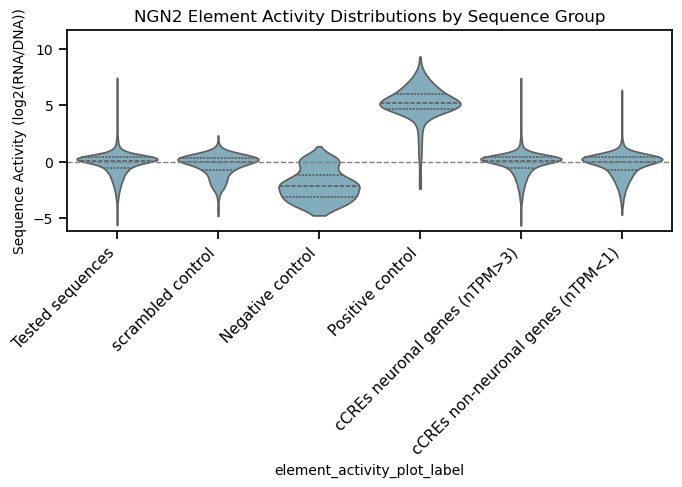

In [50]:
tested_vs_neuro_controls_scrambled = [
    "Tested sequences",
    "scrambled control",
    "Negative control",
    "Positive control",
    "cCREs neuronal genes (nTPM>3)",
    "cCREs non-neuronal genes (nTPM<1)",
]
y_lim_min = with_expression_ngn2_element_activity_df["normalized_activity_NGN2"].min()

y_lim_max = with_expression_ngn2_element_activity_df["normalized_activity_NGN2"].max()
print(f"Min and Max values: {y_lim_min}, {y_lim_max}")

costum_colors = {key: "#78B2C7" for key in tested_vs_neuro_controls_scrambled}

fig = plot_activity_by_label_groups(
    with_expression_ngn2_element_activity_df,
    label_col="element_activity_plot_label",
    activity_col="normalized_activity_NGN2",
    labels=tested_vs_neuro_controls_scrambled,
    group_size=len(tested_vs_neuro_controls_scrambled),
    kind="violin",  # "violin" or "box" or "ecdf"
    title="NGN2 Element Activity Distributions by Sequence Group",
    showfliers=False,
    notch=True,
    y_lim_min=y_lim_min - 0.5,
    y_lim_max=y_lim_max + 0.5,
    xtick_fontsize=11,
    ytick_fontsize=10,
    ylabel="Sequence Activity (log2(RNA/DNA))",
    shorten_labels=False,
    max_label_length=22,
    figsize=(7, 5),
    color_map=costum_colors,
)


figure_directoy_path = (
    "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures"
)
writing = False
if writing:
    fig.savefig(
        f"{figure_directoy_path}/ngn2_element_activity_by_label_group_violin_with_expressed.png",
        dpi=300,
    )
    fig.savefig(
        f"{figure_directoy_path}/ngn2_element_activity_by_label_group_violin_with_expressed.svg"
    )

plt.show()

### Synthetic enhancer controls (SLEA, Klein et al. 2020)
Compares NGN2 activity to the published HepG2 SLEA measurements — highly correlated
within each cell type but not between cell types, consistent with cell-type-specific
enhancer activity.

In [51]:
def contains_slea(name):
    return "SLEA" in name


def prepare_slea_name(name):
    """Strip the trailing ':(digits)' motif index off a Klein et al. SLEA name."""
    if "SLEA" in name:
        return ":".join(name.split(":")[:-1])
    return name


def generate_slea_name_from_mpra_name(name):
    if not name.startswith("C_SLEA:"):
        raise ValueError("Name does not start with C_SLEA:")
    return name.replace("C_SLEA:", "C:")


klein_etal2020_slea_path = "data/GSE142696_9MPRA.ActivityRatios.tsv.gz"
slea_klein_df = pd.read_csv(klein_etal2020_slea_path, sep="\t", skiprows=3)
slea_klein_df = slea_klein_df.loc[slea_klein_df["name"].notna()].copy()
slea_klein_df = slea_klein_df.loc[slea_klein_df["name"].apply(contains_slea)].copy()
slea_klein_df["slea_name"] = slea_klein_df["name"].apply(prepare_slea_name)
slea_klein_df = slea_klein_df.drop(columns=["name"])

slea_ngn2_df = elements_df.loc[elements_df[col_name].str.contains("C_SLEA")].copy()
slea_ngn2_df["slea_name"] = slea_ngn2_df[col_name].apply(generate_slea_name_from_mpra_name)

combined_slea = slea_ngn2_df[
    ["slea_name", "normalized_activity_NGN2", "logFC", "significant_region_NGN2", "effect_direction_NGN2"]
].merge(slea_klein_df, on="slea_name", how="inner")

slea_value_cols = [
    c for c in combined_slea.columns
    if ("WT" in c or "MT" in c or "normalized_activity_NGN2" in c) and "3'/3' MT" not in c
]
print(
    f"{combined_slea['significant_region_NGN2'].sum()} of {len(combined_slea)} SLEA controls are "
    "significantly different from scrambled."
)
print(combined_slea[slea_value_cols].corr().round(2))



4 of 194 SLEA controls are significantly different from scrambled.
                                  normalized_activity_NGN2  \
normalized_activity_NGN2                              1.00   
5'/3' WT mean log2 RNA/DNA ratio                      0.09   
5'/3' MT mean log2 RNA/DNA ratio                      0.08   
5'/5' WT mean log2 RNA/DNA ratio                      0.08   
5'/5' MT mean log2 RNA/DNA ratio                      0.08   
3'/3' WT mean log2 RNA/DNA ratio                      0.20   

                                  5'/3' WT mean log2 RNA/DNA ratio  \
normalized_activity_NGN2                                      0.09   
5'/3' WT mean log2 RNA/DNA ratio                              1.00   
5'/3' MT mean log2 RNA/DNA ratio                              0.92   
5'/5' WT mean log2 RNA/DNA ratio                              0.98   
5'/5' MT mean log2 RNA/DNA ratio                              0.97   
3'/3' WT mean log2 RNA/DNA ratio                              0.81   

       

### VISTA enhancer controls (core enhancers tested in mouse embryos)

In [52]:
vista_abbreviation_dict = {
    "branchial arch": "ba", "hindbrain": "hb", "eye": "eye", "forebrain": "fb",
    "neural tube": "nt", "midbrain": "mb", "nose": "nose", "limb": "lb",
    "cranial nerve": "cn", "dorsal root ganglion": "drg", "heart": "ht",
    "trigeminal ganglion": "tri", "somite": "som", "genital tubercle": "gen",
    "melanocytes": "mel", "tail": "tail", "facial mesenchyme": "fm", "other": "other",
    "ear": "ear", "liver": "lv", "blood vessels": "bv", "pancreas": "pan",
}
is_brain_related = ["forebrain", "midbrain", "neural tube", "hindbrain", "dorsal root ganglion", "cranial nerve"]
vista_abbreviation_to_long = {v: k for k, v in vista_abbreviation_dict.items()}


def annotate_vista_enhancers(row, name_col, only_brain_not_brain_related=False):
    """Annotate VISTA enhancers with their tested tissue(s), from abbreviations in the header."""
    annotations = sorted(long for abbr, long in vista_abbreviation_to_long.items() if abbr in row[name_col])
    if not annotations:
        raise ValueError("No VISTA annotation found")
    if only_brain_not_brain_related:
        return "brain_related" if any(a in is_brain_related for a in annotations) else "not_brain_related"
    return "VISTA_" + ",".join(annotations)


vista_enhancer_df = elements_df.loc[elements_df[col_name].str.contains("GC_Vista")].copy()
vista_enhancer_df["vista_annotation"] = vista_enhancer_df.apply(
    lambda row: annotate_vista_enhancers(row, name_col=col_name, only_brain_not_brain_related=True), axis=1
)
print(vista_enhancer_df["vista_annotation"].value_counts())
print(
    "All VISTA core enhancers tested here are annotated as active in at least one brain-related "
    "tissue in mouse embryos (forebrain, midbrain, hindbrain, neural tube, dorsal root ganglion, cranial nerve)."
)

vista_annotation
brain_related    256
Name: count, dtype: int64
All VISTA core enhancers tested here are annotated as active in at least one brain-related tissue in mouse embryos (forebrain, midbrain, hindbrain, neural tube, dorsal root ganglion, cranial nerve).


### Write to file

In [ ]:
output_path = "data/brain_cCRE_enrichment_regions.tsv.gz"
if writing:
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    readout_tested_ref_df.to_csv(output_path, sep="\t", index=False)
    print(f"Wrote brain cCRE enrichment table to {output_path}")